# Attention based models for toxic comment classification

### Utility code

In [1]:
!pip install sentencepiece wandb fasttext transformers plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653908 sha256=ebbedbed846c49d6792e0f0949aa77f081f3448df1740371cd8a65265b63905a
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [2]:
import os
import sys
from collections import defaultdict

import fasttext
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import seaborn as sns
import torch
import wandb
from huggingface_hub import hf_hub_download
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

from src import dataset, evaluation, models

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive

    drive.mount('gdrive')

Mounted at gdrive


In [3]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: daria-kay000 (daria-kay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
DATA_DIRECTORY = "gdrive/MyDrive/data/" if IS_COLAB else "../data/interim/"
TEMP_FILES = "gdrive/MyDrive/data/" if IS_COLAB else "misc/"
WANDB_PROJECT = "toxic_comment_classifier"
DEVICE = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
PAD_ID = 0
UNK_ID = 1

train_data = dataset.CommentsDataset(DATA_DIRECTORY + "train.csv")
val_data = dataset.CommentsDataset(DATA_DIRECTORY + "val.csv")
train_val_data = dataset.CommentsDataset(DATA_DIRECTORY + "train_val.csv")
test_data = dataset.CommentsDataset(DATA_DIRECTORY + "test.csv")

tiny_bert_model_name = "cointegrated/rubert-tiny2"
big_bert_model_name = "DeepPavlov/rubert-base-cased-conversational"

DEVICE

'cuda'

In [5]:
def plot_confusion_matrix_with_examples(
        y_true,
        y_pred,
        texts,
        labels,
        label_names,
        max_examples=5,
        title="Confusion Matrix"
):
    df = pd.DataFrame({
        "true": y_true,
        "pred": y_pred,
        "text": texts
    })

    def get_label_name(label):
        if label_names is None:
            return str(label)
        if isinstance(label_names, dict):
            return label_names.get(label, str(label))
        if isinstance(label_names, list):
            if 0 <= label < len(label_names):
                return label_names[label]
        return str(label)

    display_labels = [get_label_name(l) for l in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    z = cm
    text_values = cm
    colorbar_title = "Count"

    hover_text = []

    for true_label in labels:
        row = []
        for pred_label in labels:
            subset = df[
                (df["true"] == true_label) &
                (df["pred"] == pred_label)
                ]

            examples = (
                subset["text"]
                .head(100)
                .sample(frac=1.0)
                .head(max_examples)
                .reset_index()
            )

            examples_html = "<br>".join(
                f"[{row['index']}] {str(row['text'][:100])}"
                for i, row in examples.iterrows()
            )

            if not examples_html:
                examples_html = "No examples"

            cell_hover = (
                f"<b>True:</b> {get_label_name(true_label)}<br>"
                f"<b>Pred:</b> {get_label_name(pred_label)}<br>"
                f"<b>Examples:</b><br>{examples_html}"
            )

            row.append(cell_hover)

        hover_text.append(row)

    fig = go.Figure(
        data=go.Heatmap(
            z=z,
            x=display_labels,
            y=display_labels,
            text=text_values,
            hovertext=hover_text,
            hoverinfo="text",
            colorscale="Blues",
            colorbar=dict(title=colorbar_title)
        )
    )

    fig.update_traces(
        texttemplate="%{text}",
        textfont={"size": 12}
    )

    fig.update_layout(
        title=title,
        xaxis_title="Predicted label",
        yaxis_title="True label",
        yaxis=dict(autorange="reversed"),
        width=800,
        height=700
    )

    return fig


def train(model: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          criterion: torch.nn.Module,
          tokenizer: dataset.CommentsTokenizer,
          train_dataset: dataset.CommentsDataset,
          eval_dataset: dataset.CommentsDataset | None = None,
          n_epoch: int = 3,
          batch_size: int = 128,
          run_config: dict = None,
          use_sampling: bool = False,
          scheduler=None,
          ):
    # initialize the dataloaders
    train_dataloader = dataset.build_dataloader(
        train_dataset, batch_size, tokenizer, use_sampling
    )

    # set up a wandb run
    wandb_run_name = None
    if run_config:
        wandb_run_name = run_config.get("name", None)
        if wandb_run_name:
            del run_config["name"]
        run_config["batch_size"] = batch_size
        run_config["n_epoch"] = n_epoch
        run_config["optimizer"] = optimizer.__class__.__name__
        run_config["lr"] = optimizer.param_groups[0]["lr"]
        run_config["test_run"] = eval_dataset is None

    # start training loop
    with wandb.init(project=WANDB_PROJECT, name=wandb_run_name, config=run_config) as wandb_run, tqdm(
            total=len(train_dataloader) * n_epoch) as pbar:
        global_step = 0
        wandb_run.define_metric("global_step")  # required to make all graphics share the same x axis
        wandb_run.define_metric("*", step_metric="global_step")
        wandb_run.watch(model, log="all")

        for epoch in range(n_epoch):
            train_cum_loss = 0
            for X, lengths, labels in train_dataloader:
                model.train()
                X = X.to(device=DEVICE)
                labels = labels.to(device=DEVICE)
                lengths = lengths.to(device=DEVICE)
                optimizer.zero_grad()
                pred = model(X, lengths)
                loss = criterion(pred, labels)
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
                train_cum_loss += loss.item() * X.size(0)
                pbar.update()

            metrics = {"train/loss": (train_cum_loss / len(train_dataloader))}
            if eval_dataset is not None:
                eval_result = evaluation.evaluate_model(model, eval_dataset, tokenizer, criterion)
                for metric_name, metric_value in eval_result.items():
                    metrics[f"val/{metric_name}"] = metric_value
            metrics["global_step"] = global_step

            wandb_run.log(metrics)

            global_step += 1

        wandb_run.unwatch(model)

### Tokenizer setup

Для не BERT моделей токенизация текста будет проведена с помощью двух алгоритмов:
* BPE - жадное слияние наиболее частых пар символов до достижения необходимого размера словаря
* Unigram - разбиение текста на токены, которые максимизирует вероятность такого текста

Для получившихся токенов эмбеддинги инициализируются из предобученной модели `fasttext-ru-vectors`, неизвестным для этой модели токенам ставится в пару вектор из нормального распределения.

Для BERT моделей используется соответствующий предобученный токенизатор.

In [6]:
def build_embedding_matrix(tokenizer, fasttext_model, pad_id: int = PAD_ID) -> torch.Tensor:
    vocab_dim = tokenizer.vocab_size
    embed_dim = fasttext_model.get_dimension()

    # task specific tokens is going to be initialized random then learned
    embedding_params = np.random.normal(
        loc=0,
        scale=2 / (vocab_dim + embed_dim),  # variance control
        size=(vocab_dim, embed_dim),
    )
    for idx in range(vocab_dim):
        if idx == pad_id:
            embedding_params[idx] = np.zeros(embed_dim)
        token = tokenizer.decode(idx)
        if token in fasttext_model:
            embedding_params[idx] = fasttext_model[token]

    return torch.tensor(embedding_params, dtype=torch.float32)


bpe_tokenizer = dataset.SentencePieceTokenizer(
    token_type="bpe",
    vocab_size=30_000,
    train_text=iter(pl.read_csv(DATA_DIRECTORY + "train_val.csv")["comment"]),
    directory=TEMP_FILES
)
unigram_tokenizer = dataset.SentencePieceTokenizer(
    token_type="unigram",
    vocab_size=30_000,
    train_text=iter(pl.read_csv(DATA_DIRECTORY + "train_val.csv")["comment"]),
    directory=TEMP_FILES
)

fasttext_model = fasttext.load_model(
    hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
)
bpe_fasttext_embeddings = build_embedding_matrix(bpe_tokenizer, fasttext_model)
unigram_fasttext_embeddings = build_embedding_matrix(unigram_tokenizer, fasttext_model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.bin:   0%|          | 0.00/7.26G [00:00<?, ?B/s]

## Experiments

Для решения задачи мультиклассовой классификации будут сравнены несколько архитектур:

1. GRU (c разными токенайзерами, заможенными/незамороженнымим весами эмбеддингов)
2. Простой слой multihead attention поверх предобученных эмбеддингов fasttext. Пуллинг выходной последовательности векторов производится через взятие максимума/усреднение.
3. MHA с использованием positional encoding (реализован по статье https://arxiv.org/pdf/1706.03762). Для пуллинга выходной последовательности использовано взятие максимума.
4. Предобученный BERT с добавлением классифицирующей головы. Рассмотрены две модели:
    * [cointegrated/rubert-tiny2](https://huggingface.co/cointegrated/rubert-tiny2) -- дистиллированная модель [BERT](https://huggingface.co/google-bert/bert-base-multilingual-cased), обученная на задачу MLM на корпусах русского текста. Примерно 29M параметров
    * [DeepPavlov/rubert-base-cased-conversational](https://huggingface.co/DeepPavlov/rubert-base-cased-conversational) -- BERT обученный на задачи MLM и NSP на корпусах разговорного русского текста, взятых из источников вроде pikabu. Примерно 177M параметров

Все перечисленные модели будут обучаться на взвешенную кросс-энтропию, где объектам обучающей выборки соответсвующим малопредставленным классам (THREAT, OBSCENITY) соответсвует более высокий вес.

### GRU: code



In [ ]:
gru_frozen_bpe = models.GRUCommentsClassifier(
    bpe_fasttext_embeddings,
    PAD_ID,
    hidden_dim=128,
    bidirectional=False,
    num_layers=1,
    frozen_embeds=True
)
gru_frozen_bpe.to(device=DEVICE)
optim = torch.optim.AdamW(gru_frozen_bpe.parameters(), lr=1e-4, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))

config = {"name": "Frozen GRU (BPE, h_dim=128, bidirectional=False, layers=1, frozen_embeds=True)"}

train(
    gru_frozen_bpe,
    optim,
    criterion,
    bpe_tokenizer,
    train_data,
    val_data,
    n_epoch=40,
    run_config=config,
    use_sampling=False
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: daria-kay000 (daria-kay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100%|██████████| 49680/49680 [05:01<00:00, 164.94it/s]


global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▅▆▆▇▇▇▇▇▇▇███████████████████████▇███
val/INSULT-f1-score,▁▅▅▆▆▆▇▇▇▇▇▇▇▇▇█████████████████████████
val/NORMAL-PR-AUC,▁▄▅▆▆▇▇▇▇▇▇█████████████████████████████
val/NORMAL-f1-score,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████▆▇██
val/OBSCENITY-PR-AUC,▁▂▃▅▆▆▇▇▇▇▇▇████████████████████████████
val/OBSCENITY-f1-score,▁▃▄▆▇▇▇▇████████████████████████████▆▇▇▇
val/THREAT-PR-AUC,▁▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████████████
val/THREAT-f1-score,▁▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████▇███
+2,...


In [ ]:
gru_bpe = models.GRUCommentsClassifier(
    bpe_fasttext_embeddings,
    PAD_ID,
    hidden_dim=128,
    bidirectional=False,
    num_layers=1,
    frozen_embeds=False
)
gru_bpe.to(device=DEVICE)
optim = torch.optim.AdamW(gru_bpe.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))

config = {"name": "GRU (BPE, h_dim=124, bidirectional=False, layers=1, frozen_embeds=False)"}

train(
    gru_bpe,
    optim,
    criterion,
    bpe_tokenizer,
    train_data,
    val_data,
    n_epoch=30,
    run_config=config,
    use_sampling=False
)

100%|██████████| 37260/37260 [03:46<00:00, 164.19it/s]


global_step,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▆▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▂▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
val/INSULT-f1-score,▁▁▂▁▁▁▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇█████████
val/NORMAL-PR-AUC,▁▃▆▇▇█████████████████████████
val/NORMAL-f1-score,▁▁▃▄▅▅▆▇▇▇▇▇▇▇▇███████████████
val/OBSCENITY-PR-AUC,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▇▇▇███
val/OBSCENITY-f1-score,▁▁▃▃▁▁▁▁▁▂▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
val/THREAT-PR-AUC,▁▂▃▃▃▃▄▄▄▄▅▅▆▇▇▇▇▇████████████
val/THREAT-f1-score,▁▂▅▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇██████████
+2,...


In [ ]:
gru_unigram = models.GRUCommentsClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    hidden_dim=128,
    bidirectional=True,
    num_layers=4,
    frozen_embeds=False
)
gru_unigram.to(device=DEVICE)
optim = torch.optim.AdamW(gru_unigram.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))

config = {"name": "GRU (unigram, h_dim=128, bidirectional=True, layers=4, frozen_embeds=False)"}

train(
    gru_unigram,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    val_data,
    n_epoch=30,
    run_config=config,
    use_sampling=False
)

100%|██████████| 37260/37260 [03:27<00:00, 179.57it/s]


global_step,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▁▁▂▃▃▄▄▄▅▅▅▆▆▆▆▇█▇▇███▇▇▇▇▆▆▄
val/INSULT-f1-score,▁▃▅▆▇▇▇▇▇▇▇▇▇▇█████████████▇▇▆
val/NORMAL-PR-AUC,▁▅▆▇▇▇████████████████████████
val/NORMAL-f1-score,▁▄▅▆▆▇▇▇▇▇▇▇▇███████████▇▇▆▅▄▁
val/OBSCENITY-PR-AUC,▁▂▂▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇████████
val/OBSCENITY-f1-score,▁▁▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇██▇████████
val/THREAT-PR-AUC,▁▂▃▅▆▇▇▇██████████████████████
val/THREAT-f1-score,▁▂▃▄▆▆▇▇▇▇▇▇▇▇█████████████▇▇▆
+2,...


### GRU: results

Сравнение роста метрики f1-macro для моделей во время обучения на отложенной выборке:


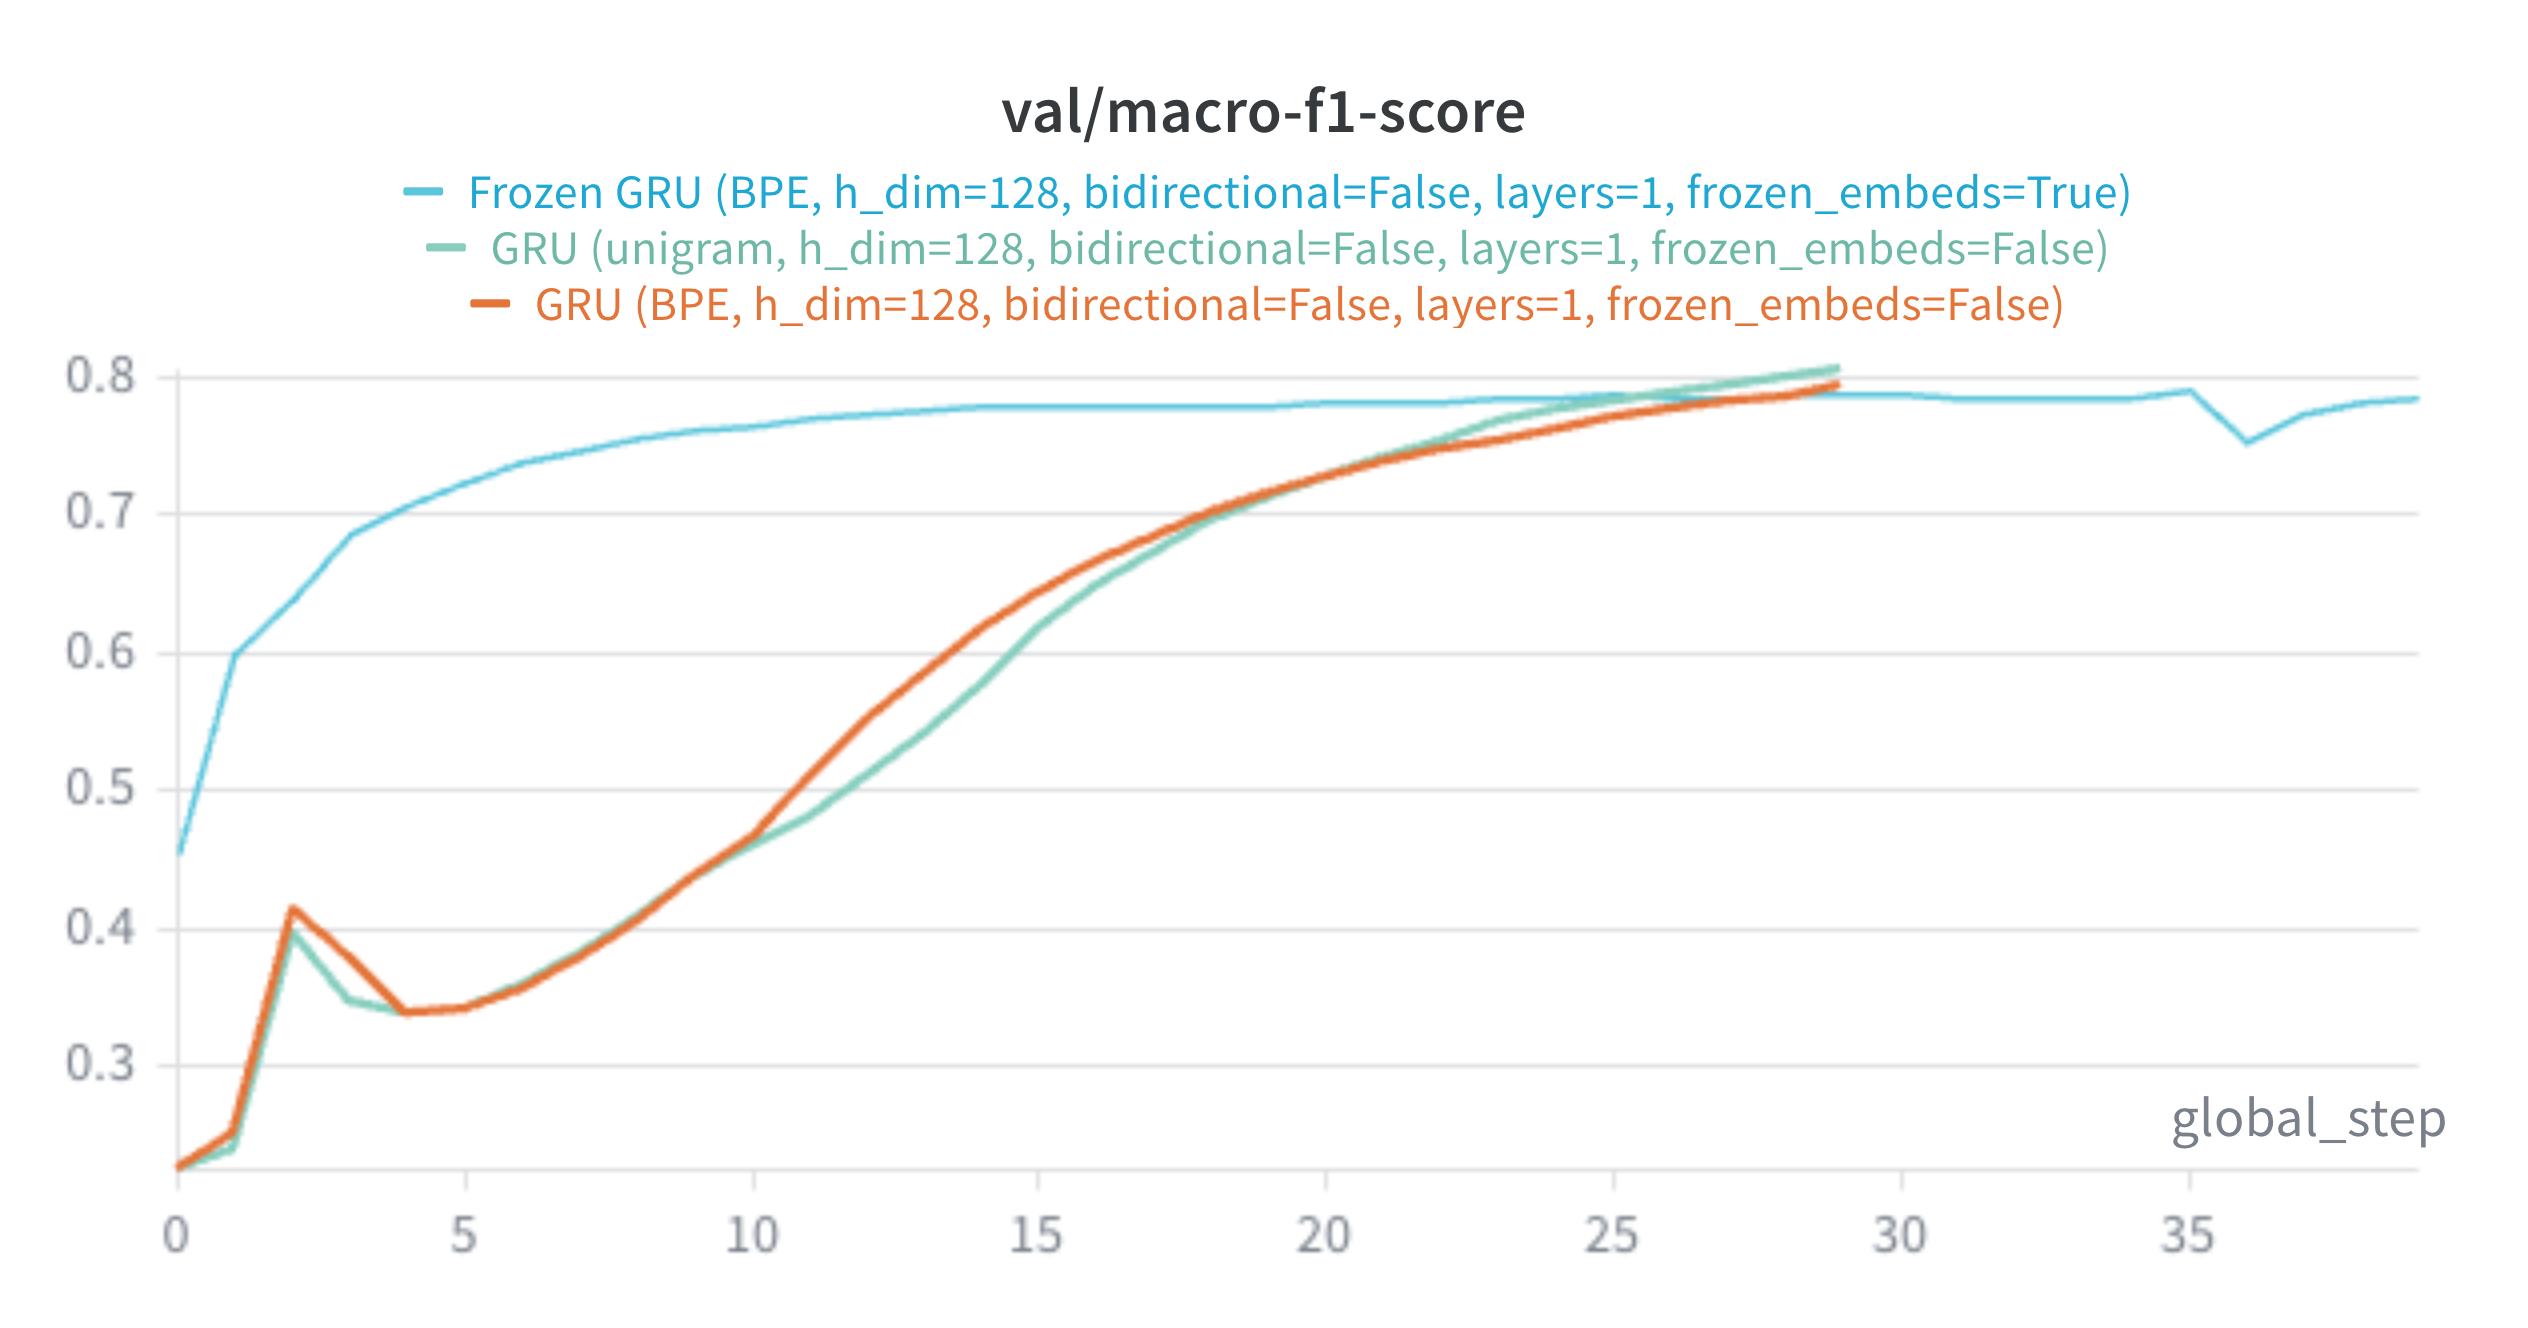

### Simple Attention

#### Mean pooling: code


In [ ]:
attn_1_mean_pooling = models.SimpleMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=1,
    pooling="mean"
)
attn_1_mean_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(attn_1_mean_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "Simple MHA (mean pooling, 1 head)"}

train(
    attn_1_mean_pooling,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=50,
    run_config=config
)

100%|██████████| 62100/62100 [04:29<00:00, 230.45it/s]


global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▄▅▇▇▇██████████████████████▇▇▇▇▇▇▇▇▇▇
val/INSULT-f1-score,▁▁▁▃▅▇▇▇████████████████████████████████
val/NORMAL-PR-AUC,▁▆▇█████████████████████████████████████
val/NORMAL-f1-score,▁▂▅▆▇█████████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆
val/OBSCENITY-PR-AUC,▁▁▂▃▅▆▇▇▇▇▇█████████████████████████████
val/OBSCENITY-f1-score,▁▁▁▂▄▆▇▇▇▇▇█████████████████████████████
val/THREAT-PR-AUC,▁▃▄▆▆▇▇▇████████████████████████████████
val/THREAT-f1-score,▁▄▅▅▆▇▇█████████████████████████████████
+2,...


In [ ]:
attn_3_mean_pooling = models.SimpleMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=3,
    pooling="mean"
)
attn_3_mean_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(attn_3_mean_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "Simple MHA (mean pooling, 3 heads)"}

train(
    attn_3_mean_pooling,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=35,
    run_config=config
)

100%|██████████| 43470/43470 [03:08<00:00, 230.40it/s]


global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▅▅▆▆▇▇▇▇████████████████████████
val/INSULT-f1-score,▁▁▁▂▄▅▆▇▇▇█████████████████████████
val/NORMAL-PR-AUC,▁▆▇████████████████████████████████
val/NORMAL-f1-score,▁▃▅▆▆▇▇▇█████████████████████▇▇▇▇▇▇
val/OBSCENITY-PR-AUC,▁▂▂▂▂▃▃▄▄▅▆▆▇▇▇▇▇██████████████████
val/OBSCENITY-f1-score,▁▁▁▁▄▅▆▆▇▇▇▇▇▇█████████████████████
val/THREAT-PR-AUC,▁▂▃▄▄▅▆▆▇▇▇▇███████████████████████
val/THREAT-f1-score,▁▄▅▅▆▆▇▇▇▇█████████████████████████
+2,...


In [ ]:
attn_5_mean_pooling = models.SimpleMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=5,
    pooling="mean"
)
attn_5_mean_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(attn_5_mean_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "Simple MHA (mean pooling, 5 heads)"}

train(
    attn_5_mean_pooling,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=35,
    run_config=config
)

100%|██████████| 43470/43470 [03:09<00:00, 229.58it/s]


global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▄▅▅▆▆▇▇▇▇███████████████████████
val/INSULT-f1-score,▁▁▁▂▄▅▆▇▇▇█████████████████████████
val/NORMAL-PR-AUC,▁▆▇▇███████████████████████████████
val/NORMAL-f1-score,▁▂▅▆▆▇▇▇▇█████████████████████▇▇▇▇▇
val/OBSCENITY-PR-AUC,▁▂▂▂▂▃▃▄▄▅▅▆▆▇▇▇▇██████████████████
val/OBSCENITY-f1-score,▁▂▁▁▄▅▆▆▇▇▇▇▇▇█████████████████████
val/THREAT-PR-AUC,▁▂▃▄▄▅▆▆▇▇▇▇▇██████████████████████
val/THREAT-f1-score,▁▄▅▅▆▆▇▇▇▇█████████████████████████
+2,...


#### Mean pooling: results

Сравенение моделей по f1-macro на отложенной выборке во время обучения:

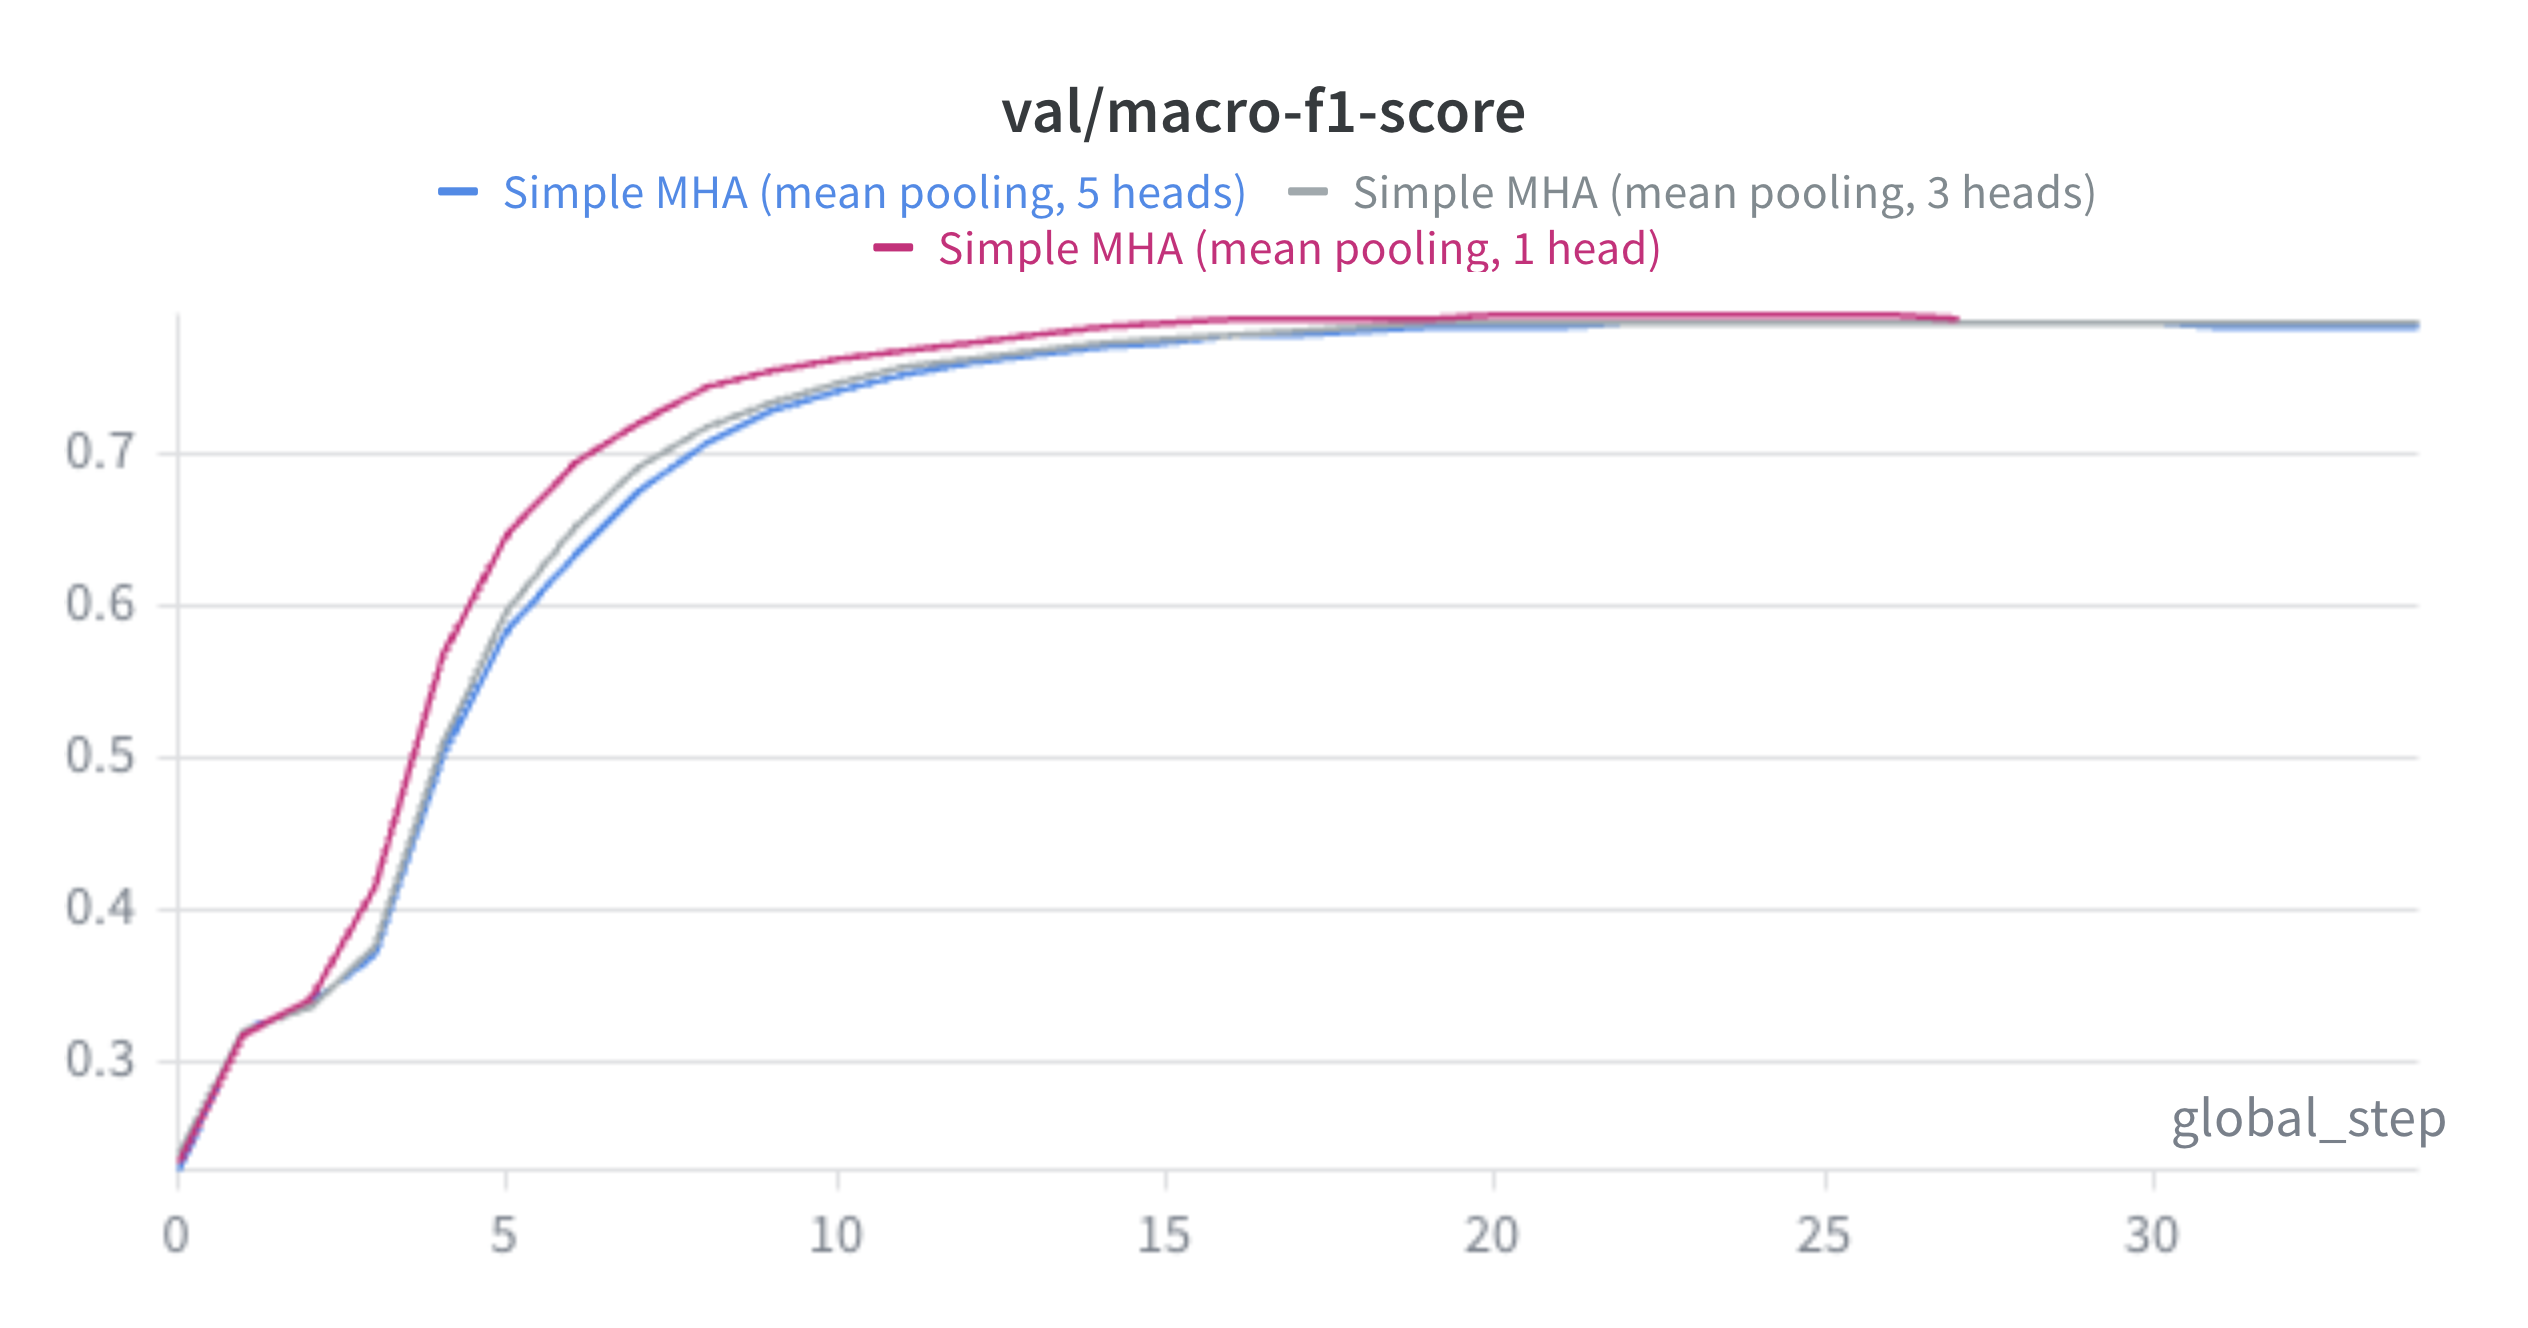

**Вывод:** эксперимент показал что большее количество голов медленнее обучается, но при этом не дает никакого прироста в качестве.

#### Max pooling: code

In [ ]:
attn_1_max_pooling = models.SimpleMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=1,
    pooling="max"
)
attn_1_max_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(attn_1_max_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "Simple MHA (max pooling, 1 head)"}

train(
    attn_1_max_pooling,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=35,
    run_config=config
)

100%|██████████| 43470/43470 [03:10<00:00, 228.57it/s]


global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▅▆▆▇▇▇██████████████████████▇▇▇▇
val/INSULT-f1-score,▁▁▁▅▆▇▇▇███████████████████████████
val/NORMAL-PR-AUC,▁▆▇████████████████████████████████
val/NORMAL-f1-score,▁▂▅▇▇████████████████████████▇▇▇▇▇▇
val/OBSCENITY-PR-AUC,▁▂▂▂▃▃▄▅▆▇▇▇▇██████████████████████
val/OBSCENITY-f1-score,▁▁▁▃▄▆▇▇▇██████████████████████████
val/THREAT-PR-AUC,▁▂▃▄▅▆▇▇▇██████████████████████████
val/THREAT-f1-score,▁▄▅▆▇▇▇▇███████████████████████████
+2,...


In [ ]:
attn_3_max_pooling = models.SimpleMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=3,
    pooling="max"
)
attn_3_max_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(attn_3_max_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "Simple MHA (max pooling, 3 heads)"}

train(
    attn_3_max_pooling,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=35,
    run_config=config
)

100%|██████████| 43470/43470 [03:10<00:00, 228.07it/s]


global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▄▅▆▆▇▇▇█████████████████████▇▇▇▇▇
val/INSULT-f1-score,▁▁▁▄▅▆▇▇▇██████████████████████████
val/NORMAL-PR-AUC,▁▆▇████████████████████████████████
val/NORMAL-f1-score,▁▂▅▆▇▇█████████████████████████████
val/OBSCENITY-PR-AUC,▁▂▂▂▂▃▄▅▆▆▇▇▇▇▇████████████████████
val/OBSCENITY-f1-score,▁▁▁▃▄▆▆▇▇▇▇████████████████████████
val/THREAT-PR-AUC,▁▂▃▃▄▅▆▆▇▇▇████████████████████████
val/THREAT-f1-score,▁▄▅▅▆▇▇▇▇██████████████████████████
+2,...


#### Max pooling: results
Сравнение моделей по f1-macro на отложенной выборке во время обучения:

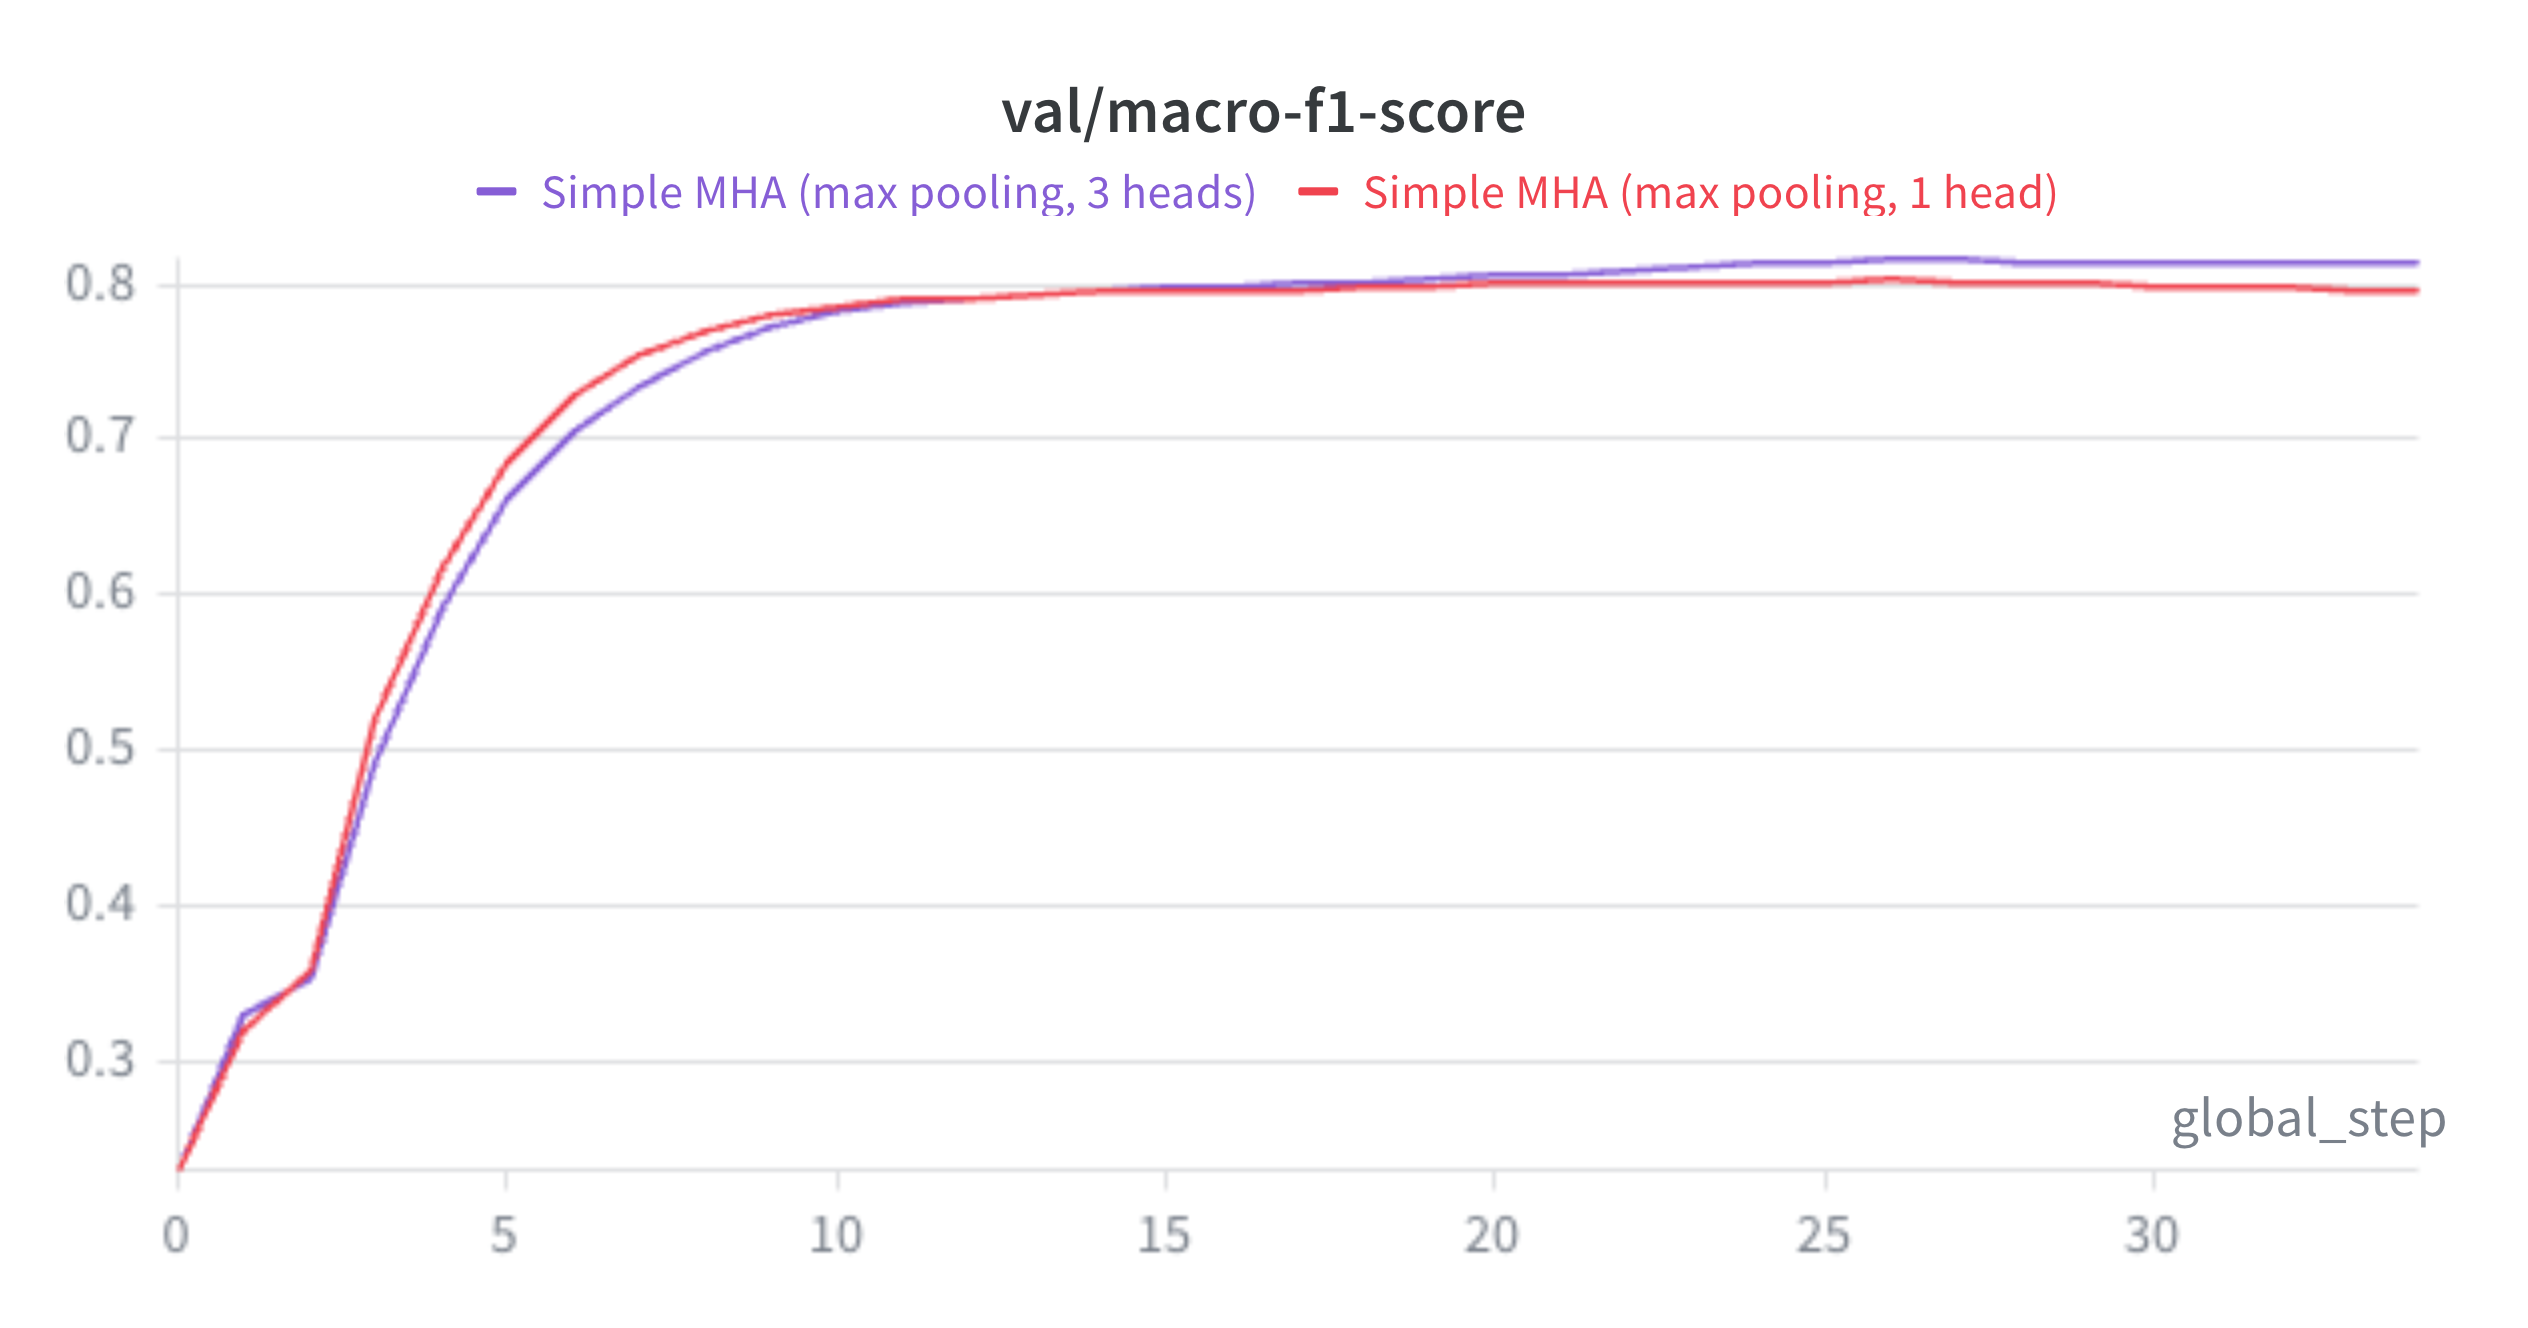

**Выводы:** при взятии максимума по каждому измерению среди векторов выходной последовательности, качество классификации получается лучше по сравенению с взятием среднего, причем большее количество голов дает лучший результат.

### Attention with positional encoding: code

In [ ]:
pos_mha = models.PosEncMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=3
)
pos_mha.to(device=DEVICE)
optim = torch.optim.AdamW(pos_mha.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "MHA with pos enc (3 heads, no window)"}

num_epochs = 50
batch_size = 128
num_training_steps = (len(train_data) // batch_size) * num_epochs

# scheduler = PolynomialLR(
#     optim,
#     power=2,
#     total_iters=num_training_steps
# )

train(
    pos_mha,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=num_epochs,
    batch_size=batch_size,
    run_config=config
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: daria-kay000 (daria-kay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100%|██████████| 62100/62100 [04:31<00:00, 228.44it/s]


global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/loss,██▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▂▃▄▅▆▆▇▇▇████████████████████▇▇▇▇▇▇▇▇▇▇
val/INSULT-f1-score,▁▁▂▂▃▄▅▆▆▇▇▇████████████████████████████
val/NORMAL-PR-AUC,▂▁▄▆▇███████████████████████████████████
val/NORMAL-f1-score,▆▆▁▄▇███████████████████████████████████
val/OBSCENITY-PR-AUC,▁▁▁▂▂▂▃▄▄▅▆▇▇▇▇█████████████████████████
val/OBSCENITY-f1-score,▁▁▁▁▁▁▂▄▅▅▆▇▇▇██████████████████████████
val/THREAT-PR-AUC,▁▂▂▃▄▅▆▆▇▇▇█████████████████████████████
val/THREAT-f1-score,▁▃▂▃▄▅▅▆▆▆▇▇▇▇██████████████████████████
+2,...


In [ ]:
pos_mha_window = models.PosEncMHAClassifier(
    unigram_fasttext_embeddings,
    PAD_ID,
    num_heads=3,
    attn_window=20
)
pos_mha_window.to(device=DEVICE)
optim = torch.optim.AdamW(pos_mha_window.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": "MHA with pos enc (3 heads, window=20)"}

num_epochs = 50
batch_size = 128
num_training_steps = (len(train_data) // batch_size) * num_epochs

# scheduler = PolynomialLR(
#     optim,
#     power=2,
#     total_iters=num_training_steps
# )

train(
    pos_mha_window,
    optim,
    criterion,
    unigram_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=num_epochs,
    batch_size=batch_size,
    run_config=config
)

100%|██████████| 62100/62100 [04:46<00:00, 216.68it/s]


global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/loss,██▆▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▂▃▄▄▅▆▆▆▇▇██████████████████████▇▇▇▇▇▇▇
val/INSULT-f1-score,▁▁▂▃▃▄▅▆▇▇▇▇▇▇▇█████████████████████████
val/NORMAL-PR-AUC,▁▁▄▆▇███████████████████████████████████
val/NORMAL-f1-score,▁▁▁▁▄▆▇▇▇███████████████████████████████
val/OBSCENITY-PR-AUC,▁▁▁▁▁▂▂▂▂▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇███████████████
val/OBSCENITY-f1-score,▁▁▁▁▁▁▂▃▄▅▆▆▆▆▇▇▇▇▇▇████████████████████
val/THREAT-PR-AUC,▁▂▂▃▄▅▅▆▆▆▇▇▇▇▇█████████████████████████
val/THREAT-f1-score,▁▁▃▄▄▅▅▆▆▇▇▇▇▇██████████████████████████
+2,...


### Attention with positional encoding: results

К каждому эмбеддингу входной последовательности был прибавлен вектор, кодирующий позицию текущего токена в исходном тексте. Было рассмотрено две модели:

* attention + positional encoding
* masked attention + positional encoding

Во втором варианте, attention score для всех токенов, выходящих за окно шириной в 10 токенов по обе стороны от центрального токена, искусственно приравнен 0. Таким образом, осуществилась проверка гипотезы, что информация о токсичности конкретного токена определяется небольшим контекстным окном.

На графике показано сравение f1-macro на отложенной выборке во время обучения моделей.

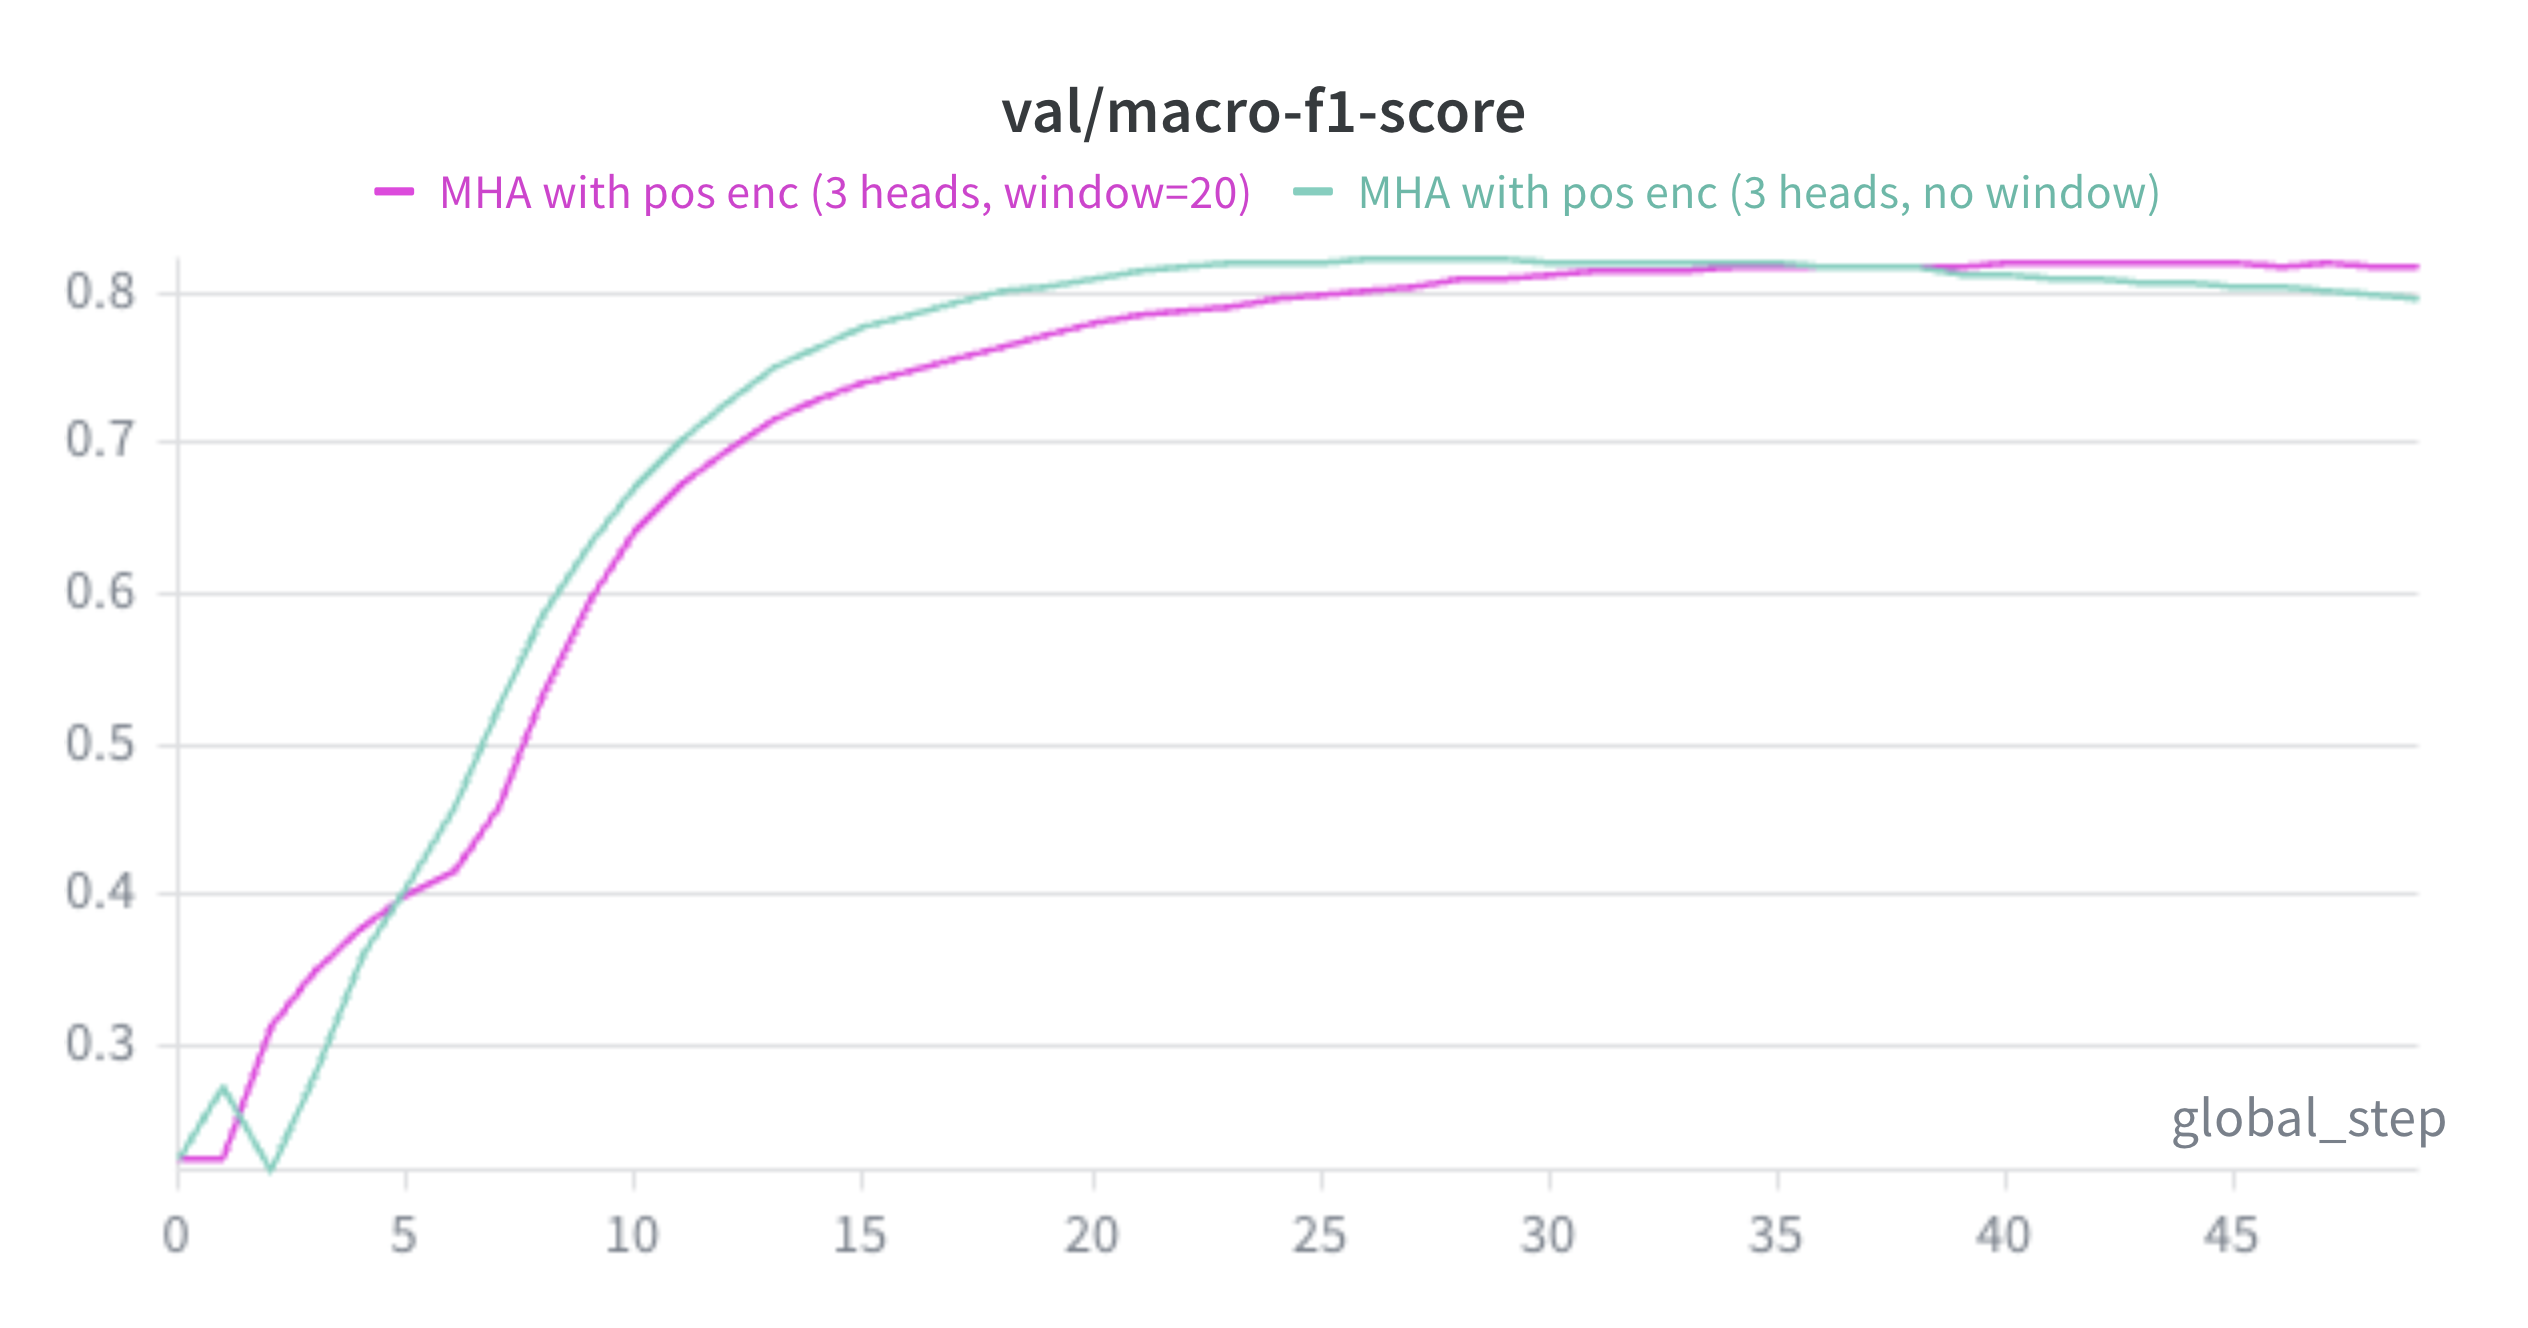

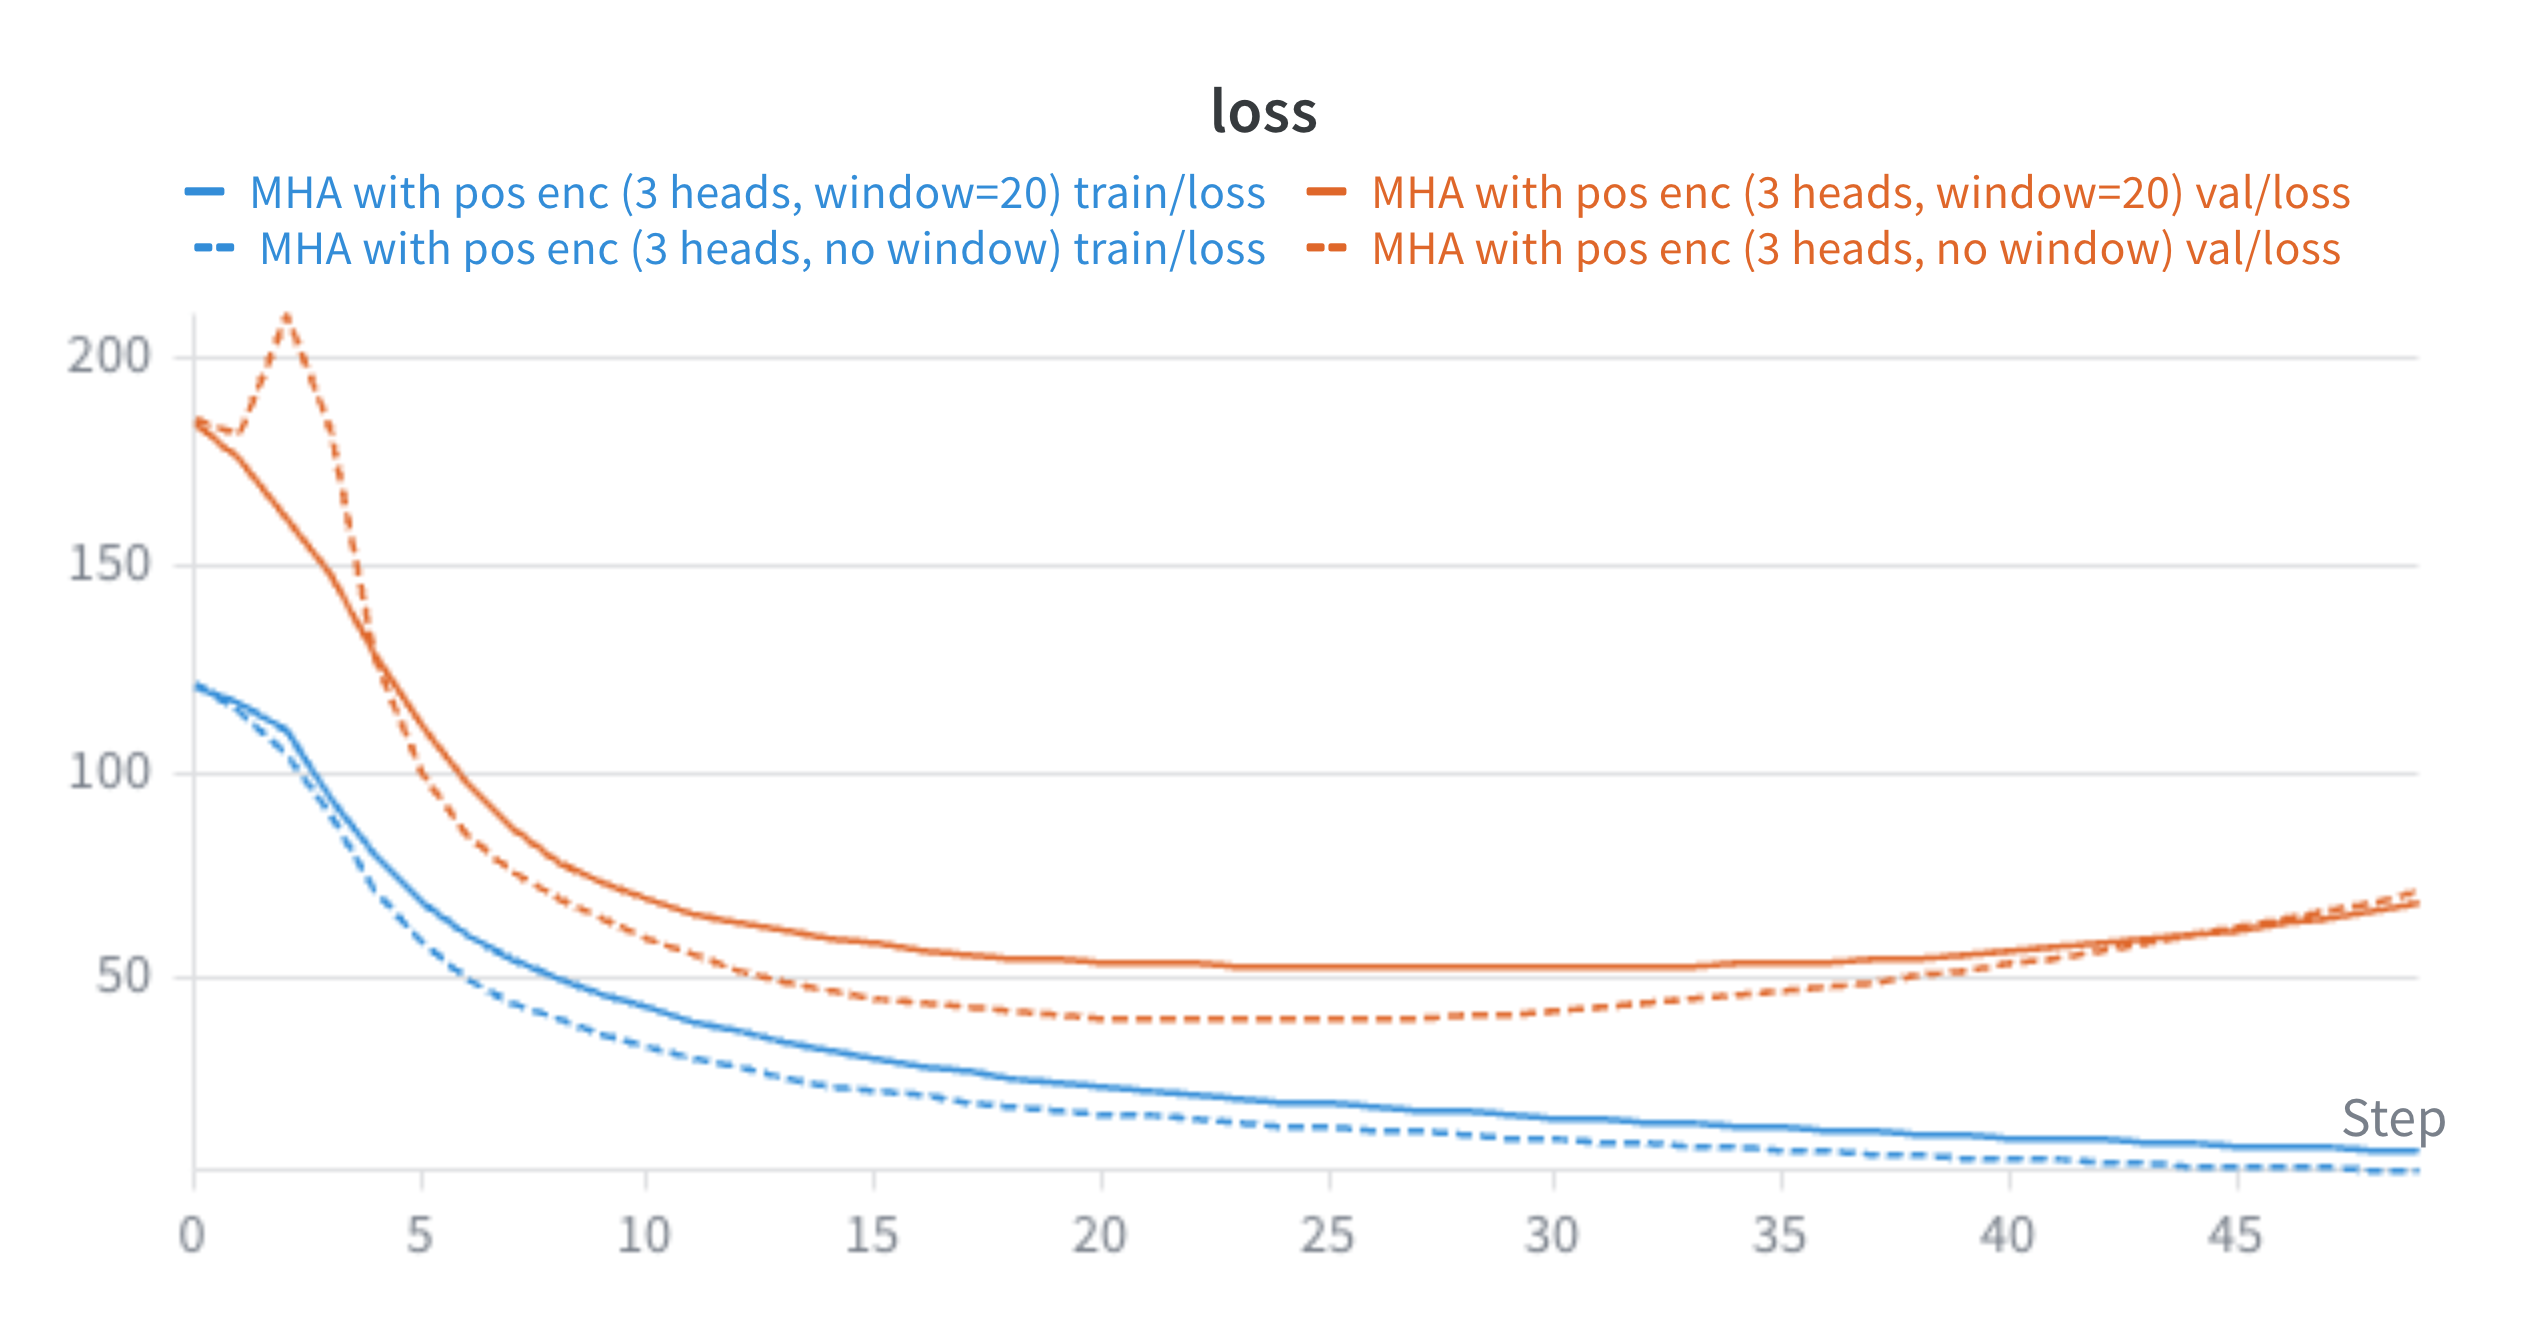

**Вывод**: masked attention медленнее обучался, но показал более высокое качество классификации. Так же, по графику падения лосса видно, что модель простая модель начала быстрее переобучаться.

### BERT finetuning

### rubert-tiny2: code

In [ ]:
clf_name = f"Pretrained BERT ({tiny_bert_model_name})"

bert_tiny_tokenizer = dataset.CommentsBertTokenizer(tiny_bert_model_name)
tiny_bert = models.PretrainedBertClassifier(tiny_bert_model_name)
tiny_bert.to(device=DEVICE)
optim = torch.optim.AdamW(tiny_bert.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": f"{clf_name} default pooling"}

train(
    tiny_bert,
    optim,
    criterion,
    bert_tiny_tokenizer,
    train_data,
    val_data,
    run_config=config,
    n_epoch=20,
    batch_size=(128 + 64)
)

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


100%|██████████| 16560/16560 [04:48<00:00, 57.44it/s]


global_step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▂▄▃▁▃▂▅▆▆▆▆█▇▇█▇▇▇▇▇
val/INSULT-f1-score,▁▅▅▄▅▄▆▆▆▇▆█▇▇██▇█▇▇
val/NORMAL-PR-AUC,▁▅▆▇▇▇██████████████
val/NORMAL-f1-score,▁▆▆▃▃▂▆▆▆▆▆█▇▇██▇█▆▆
val/OBSCENITY-PR-AUC,▁▅▆▇▇▇██████████████
val/OBSCENITY-f1-score,▁▄▄▄▅▅▆▇▇▇▇█▇██▇██▇▇
val/THREAT-PR-AUC,▁▆▇▇▇▇█████████████▇
val/THREAT-f1-score,▁▄▄▅▅▃▅▆▅▅▆█▆▇█▇▇▇▆▇
+2,...


In [ ]:
clf_name = f"Pretrained BERT ({tiny_bert_model_name})"

bert_tiny_tokenizer = dataset.CommentsBertTokenizer(tiny_bert_model_name)
tiny_bert_max_pooling = models.PretrainedBertClassifier(tiny_bert_model_name, pooling="max")
tiny_bert_max_pooling.to(device=DEVICE)
optim = torch.optim.AdamW(tiny_bert_max_pooling.parameters(), lr=1e-5, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.1, 0.4, 0.4], device=DEVICE))
config = {"name": f"{clf_name} max pooling"}

train(
    tiny_bert_max_pooling,
    optim,
    criterion,
    bert_tiny_tokenizer,
    train_data,
    val_data,
    run_config=config,
    n_epoch=20,
    batch_size=(128 + 64)
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


100%|██████████| 16560/16560 [04:47<00:00, 57.53it/s]


global_step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▂▂▂▂▃▄▄▅▆▆▆▆▇▇▇▇▇██
val/INSULT-f1-score,▁▃▄▄▄▄▅▅▆▆▇▇▇▇▇▇▇▇██
val/NORMAL-PR-AUC,▁▅▆▇▇▇██████████████
val/NORMAL-f1-score,▁▅▃▂▁▂▂▃▄▅▆▆▆▆▇▇▇▇██
val/OBSCENITY-PR-AUC,▁▅▆▇▇▇██████████████
val/OBSCENITY-f1-score,▁▄▅▅▅▅▅▆▆▇▇▇▇▇██████
val/THREAT-PR-AUC,▁▅▆▇▇▇▇▇████████████
val/THREAT-f1-score,▁▃▄▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇██
+2,...


### rubert-tiny2: results

Для текущей архитектуры было сравнено два типа присоединения классифицирующей головы:

* линейный слой поверх cls токена BERT
* линейный слой поверх max pooling векторов выходной последовательности  

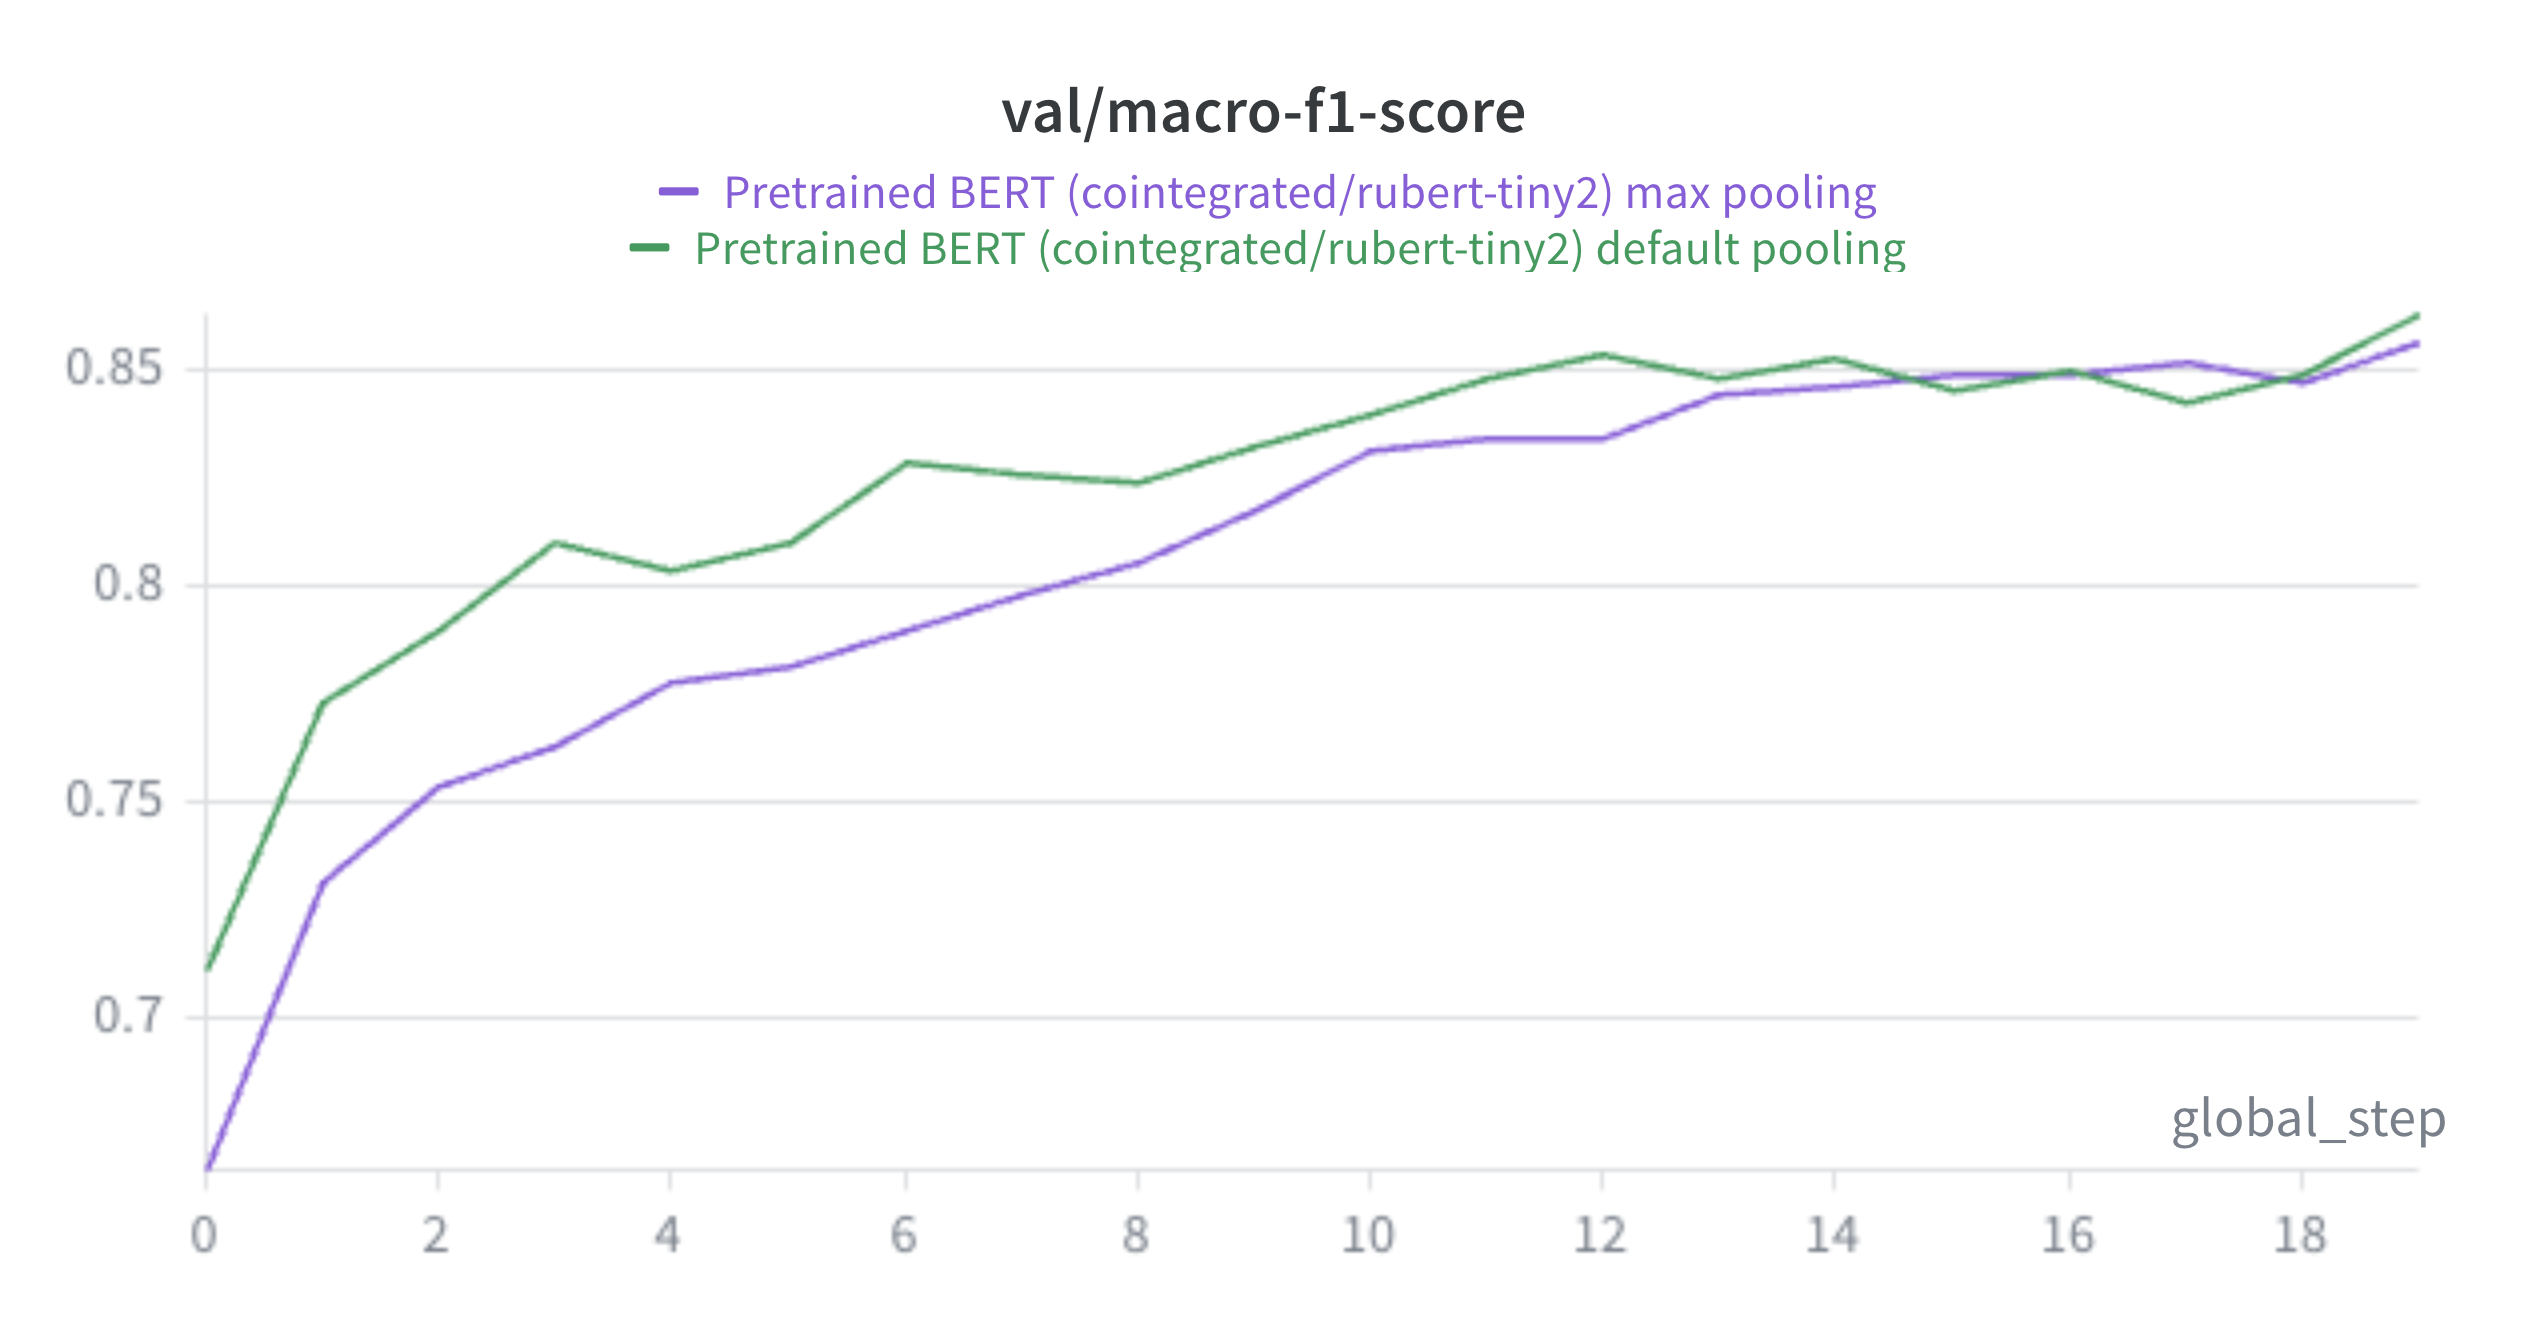

**Вывод:** классификация текста на основе эмбеддинга для cls токена показала себя лучше

### rubert-conversational: code

In [ ]:
clf_name = f"Pretrained BERT ({big_bert_model_name}) default pooling"

big_bert_tokenizer = dataset.CommentsBertTokenizer(big_bert_model_name)
big_bert = models.PretrainedBertClassifier(big_bert_model_name)
big_bert.to(device=DEVICE)
optim = torch.optim.AdamW(big_bert.parameters(), lr=1e-6, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
config = {"name": f"{clf_name}"}

train(
    big_bert,
    optim,
    criterion,
    big_bert_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=20,
    batch_size=(128 + 64),
    run_config=config
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


100%|██████████| 16560/16560 [29:09<00:00,  9.47it/s]


global_step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▃▅▅▆▇▇▇▇▇██████████
val/INSULT-f1-score,▁▂▄▅▆▆▆▇▇▇▇▇▇▇█▇████
val/NORMAL-PR-AUC,▁▅▆▆▆▇▇▇▇███████████
val/NORMAL-f1-score,▁▃▄▅▆▆▇▇▇▇▇█▇███████
val/OBSCENITY-PR-AUC,▁▅▇▇████████████████
val/OBSCENITY-f1-score,▁▅▆▆▇▇▇▇▇▇██████████
val/THREAT-PR-AUC,▁▅▇▇▇▇██████████████
val/THREAT-f1-score,▁▄▅▅▆▆▇▇▇▇▇▇▇▇█▇████
+2,...


In [ ]:
clf_name = f"Pretrained BERT ({big_bert_model_name}) max pooling"

big_bert_tokenizer = dataset.CommentsBertTokenizer(big_bert_model_name)
big_bert = models.PretrainedBertClassifier(big_bert_model_name)
big_bert.to(device=DEVICE)
optim = torch.optim.AdamW(big_bert.parameters(), lr=1e-6, fused=True)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.1, 0.4, 0.4], device=DEVICE))
config = {"name": f"{clf_name}"}

train(
    big_bert,
    optim,
    criterion,
    big_bert_tokenizer,
    train_data,
    eval_dataset=val_data,
    n_epoch=20,
    batch_size=(128 + 64),
    run_config=config
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


100%|██████████| 16560/16560 [29:10<00:00,  9.46it/s]


global_step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/INSULT-PR-AUC,▁▄▅▆▆▆▇▇▇▇█▇████████
val/INSULT-f1-score,▁▂▄▄▅▆▆▇▇▇▇▇▇▇██████
val/NORMAL-PR-AUC,▁▅▆▆▇▇▇▇████████████
val/NORMAL-f1-score,▁▄▅▅▆▆▇▇▇▇▇▇▇███████
val/OBSCENITY-PR-AUC,▁▅▇▇████████████████
val/OBSCENITY-f1-score,▁▄▅▆▆▆▆▇▇▇▇▇▇▇██████
val/THREAT-PR-AUC,▁▄▆▆▇▇▇▇▇▇██████████
val/THREAT-f1-score,▁▄▅▅▆▆▆▇▇▇█▇▇███████
+2,...


### rubert-conversational: results

Сравенение моделей по метрике f1-macro на отложенной выборке:

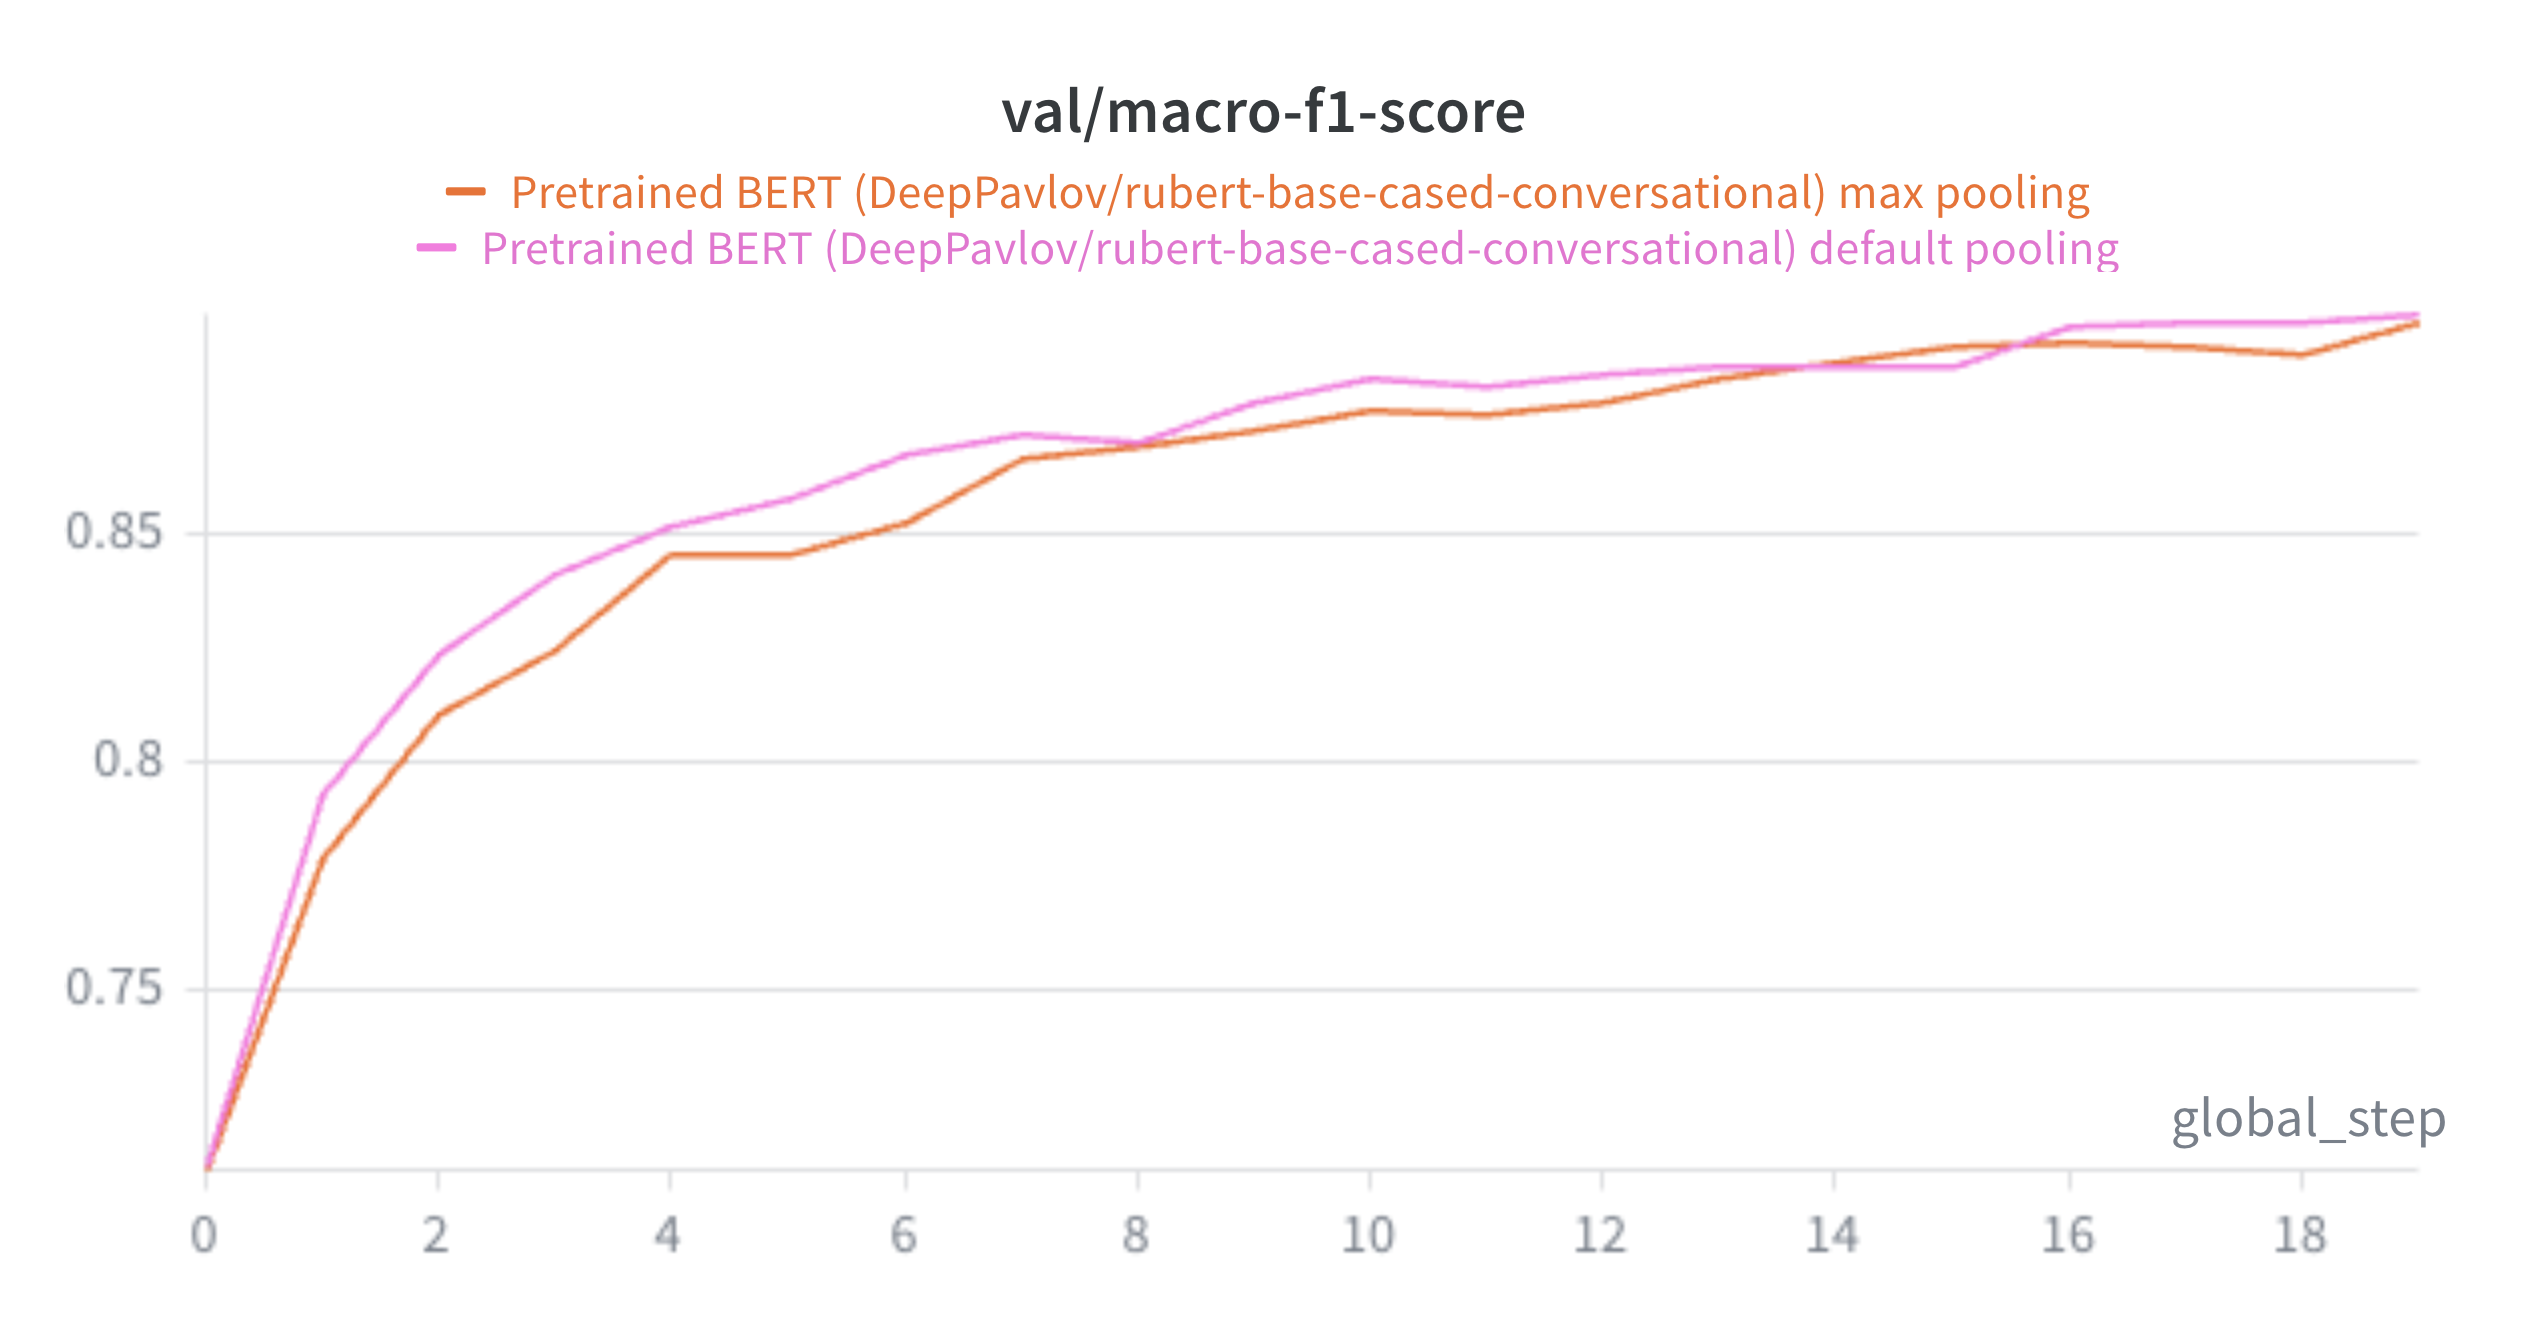

**Вывод:** для данной модели классификация на основе cls токена так же показала себя лучше

## Evaluation

Среди всех проведенных экспериментов отобраны лучшие модели, они обучены на объединении валидационной и тренировочной выборок

In [7]:
best_models = [
    (
        "GRU",
        models.GRUCommentsClassifier(unigram_fasttext_embeddings, PAD_ID, hidden_dim=128, bidirectional=True,
                                     num_layers=3),
        1e-5,
        20,
        unigram_tokenizer
    ),
    (
        "Simple MHA",
        models.SimpleMHAClassifier(unigram_fasttext_embeddings, PAD_ID, num_heads=3, pooling="max"),
        1e-5,
        25,
        unigram_tokenizer
    ),
    (
        "MHA with positional encoding",
        models.PosEncMHAClassifier(unigram_fasttext_embeddings, PAD_ID, num_heads=3, attn_window=20),
        1e-5,
        38,
        unigram_tokenizer
    ),
    (
        tiny_bert_model_name,
        models.PretrainedBertClassifier(tiny_bert_model_name),
        1e-5,
        12,
        dataset.CommentsBertTokenizer(tiny_bert_model_name)
    ),
    (
        big_bert_model_name,
        models.PretrainedBertClassifier(big_bert_model_name),
        1e-6,
        15,
        dataset.CommentsBertTokenizer(big_bert_model_name)
    ),
]

report_data = defaultdict(list)
for name, model, lr, num_epochs, tokenizer in best_models:
    file_name = TEMP_FILES + f"{name.replace("/", "_")}_state.pt"
    if os.path.exists(file_name):
        model.load_state_dict(torch.load(file_name))
        model.to(device=DEVICE)
    else:
        optim = torch.optim.AdamW(model.parameters(), lr=lr, fused=True)
        criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.2, 0.3, 0.4], device=DEVICE))
        config = {"name": f"[test run] {name}"}
        model.to(device=DEVICE)
        train(model, optim, criterion, tokenizer, train_val_data, n_epoch=num_epochs, batch_size=128, run_config=config)
        torch.save(model.state_dict(), file_name)

    eval_result = evaluation.evaluate_model(model, test_data, tokenizer)

    report_data["name"].append(name)
    for key, val in eval_result.items():
        if "PR-AUC" not in key:
            report_data[key].append(val)

pd.DataFrame(report_data).style.background_gradient(cmap="Blues")

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,name,macro_f1_score,NORMAL-f1-score,INSULT-f1-score,THREAT-f1-score,OBSCENITY-f1-score
0,GRU,0.841636,0.978797,0.822567,0.834065,0.731115
1,Simple MHA,0.817423,0.972359,0.781741,0.777097,0.738494
2,MHA with positional encoding,0.819772,0.974386,0.789087,0.774194,0.741422
3,cointegrated/rubert-tiny2,0.833602,0.978128,0.814325,0.804071,0.737883
4,DeepPavlov/rubert-base-cased-conversational,0.892608,0.987492,0.881825,0.878029,0.823085


Построим матрицу ошибок для полученных моделей:

In [8]:
texts, _ = zip(*iter(test_data))
model_predictions = []
for name, model, _, _, tokenizer in best_models:
    model.to(device=DEVICE)
    true_labels, pred_probas, _ = evaluation.get_predictions(model, test_data, tokenizer)
    model_predictions.append((name, true_labels, np.array(pred_probas)))

In [9]:
for name, true_labels, pred_probas in model_predictions:
    fig = plot_confusion_matrix_with_examples(
        y_true=true_labels,
        y_pred=np.array(pred_probas).argmax(axis=1).tolist(),
        texts=texts,
        labels=test_data.label_idx,
        label_names=test_data.label_names,
        max_examples=10,
        title=f"{name} confusion matrix"
    )

    fig.show()

Построим precision-recall кривую:

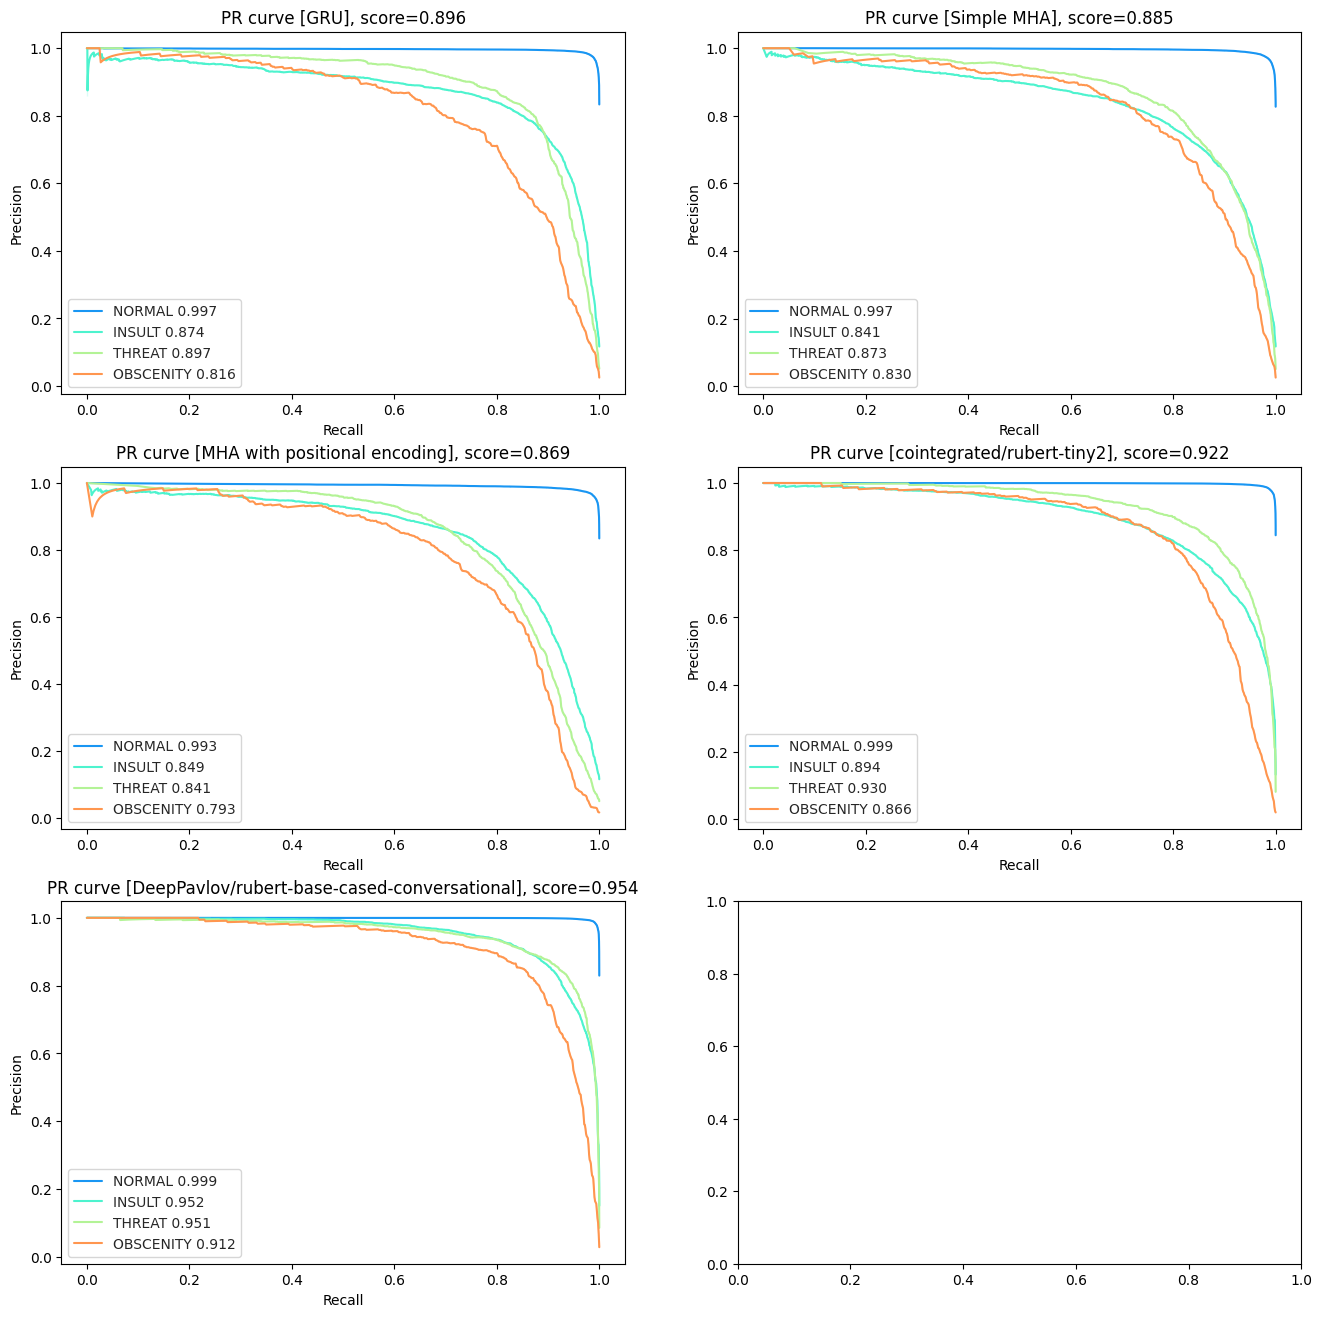

In [14]:
n_classes = test_data.label_names
colors = sns.color_palette('rainbow', len(n_classes))
results = []
for name, true_labels, pred_probas in model_predictions:
    y_true_bin = label_binarize(true_labels, classes=test_data.label_idx)
    prec, rec = {}, {}
    ap_macro = average_precision_score(true_labels, pred_probas, average="macro")
    ap_per_class = []
    for i, class_name in enumerate(n_classes):
        per_class = average_precision_score(y_true_bin[:, i], pred_probas[:, i])
        ap_per_class.append(f"{class_name} {per_class:.3f}")
        prec[i], rec[i], _ = precision_recall_curve(y_true_bin[:, i], pred_probas[:, i])
    results.append((name, prec, rec, ap_macro, ap_per_class))

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()[:-1]
for i, ax in enumerate(axes):
    name, prec, rec, score, classes = results[i]
    with sns.axes_style("whitegrid"):
        for j in range(len(classes)):
            sns.lineplot(x=rec[j], y=prec[j], label=classes[j], color=colors[j], ax=ax)
        ax.set_title(f"PR curve [{name}], score={score:.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
plt.show()

Финальная таблица ранжирования моделей:



In [13]:
model_ranging = defaultdict(list)
for name, true_labels, pred_probas in model_predictions:
    model_ranging["name"].append(name)
    model_ranging["f1-macro"].append(f1_score(true_labels, pred_probas.argmax(axis=1), average="macro"))
    model_ranging["pr-auc-macro"].append(average_precision_score(true_labels, pred_probas, average="macro"))

pd.DataFrame(model_ranging).style.background_gradient(cmap="Blues")

,name,f1-macro,pr-auc-macro
0,GRU,0.841636,0.895872
1,Simple MHA,0.817423,0.885229
2,MHA with positional encoding,0.819772,0.868989
3,cointegrated/rubert-tiny2,0.833602,0.922260
4,DeepPavlov/rubert-base-cased-conversational,0.892608,0.953518


**Выводы:**

* Среди рассмотренных моделей fine-tuned BERT показал себя лучше всего, особенно модель обученная на корпусах с неформальным русским языком. Хотя нельзя однозначно сделать вывод о том, что сыграло ключевую роль -- данные на которых была обучена модель или количество параметров.
* Интересно также, что практически все модели лучше определяют класс THREAT, чем INSULT (судя по графикам PR), несмотря на то, что первый встречается в данных сильно реже. Это согласуется с результатами, полученными во время кластеризации комментариев. В датасете много THREAT комментариев содержат формы слова "расстрелять", поэтому этот класс определять легче.
* GRU показывает качество, сравнимое с небольшой моделью finetuned BERT (cointegrated/rubert-tiny2) по метрике f1-macro. В то время как значение pr-auс больше у BERT (cointegrated/rubert-tiny2). Это говорит о не удачном выборе порога в 0.5, другой порог дал бы лучшее значение f1-macro для модели BERT.